# Monte Carlo (Call) Option Pricer 

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import yfinance as yf
# from numba import jit

In [2]:
import sys
sys.path.append('.')
from MC_Pricer import MonteCarlo_GBM, MonteCarlo_Heston

In [3]:
import matplotlib as mpl
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.titlesize'] = 20

# B-S Model

## Illustration

In [4]:
data = yf.download("AAPL", period="1y")["Close"]

[*********************100%***********************]  1 of 1 completed


In [5]:
log_returns = np.log(data / data.shift(1)).dropna()
r_free = 3.7e-2         # as of 05.04.2026
S0 = data.iloc[-1, 0]
sigma_year = log_returns.std()['AAPL'] * np.sqrt(252) 

In [6]:
today = pd.Timestamp.today().normalize()
expiry = pd.Timestamp("2028-12-15")

# Count trading days using the US trading calendar
trading_days = pd.bdate_range(today, expiry)  # business days only
n = len(trading_days)
T = n / 252

In [7]:
mc = MonteCarlo_GBM(USE_NUMBA=False)
mc.load(S0=S0, K=210, sigma=sigma_year, r_free=r_free)

In [8]:
C, trajectory = mc.mc_simulation(T, n_samples=20, n_steps=100)

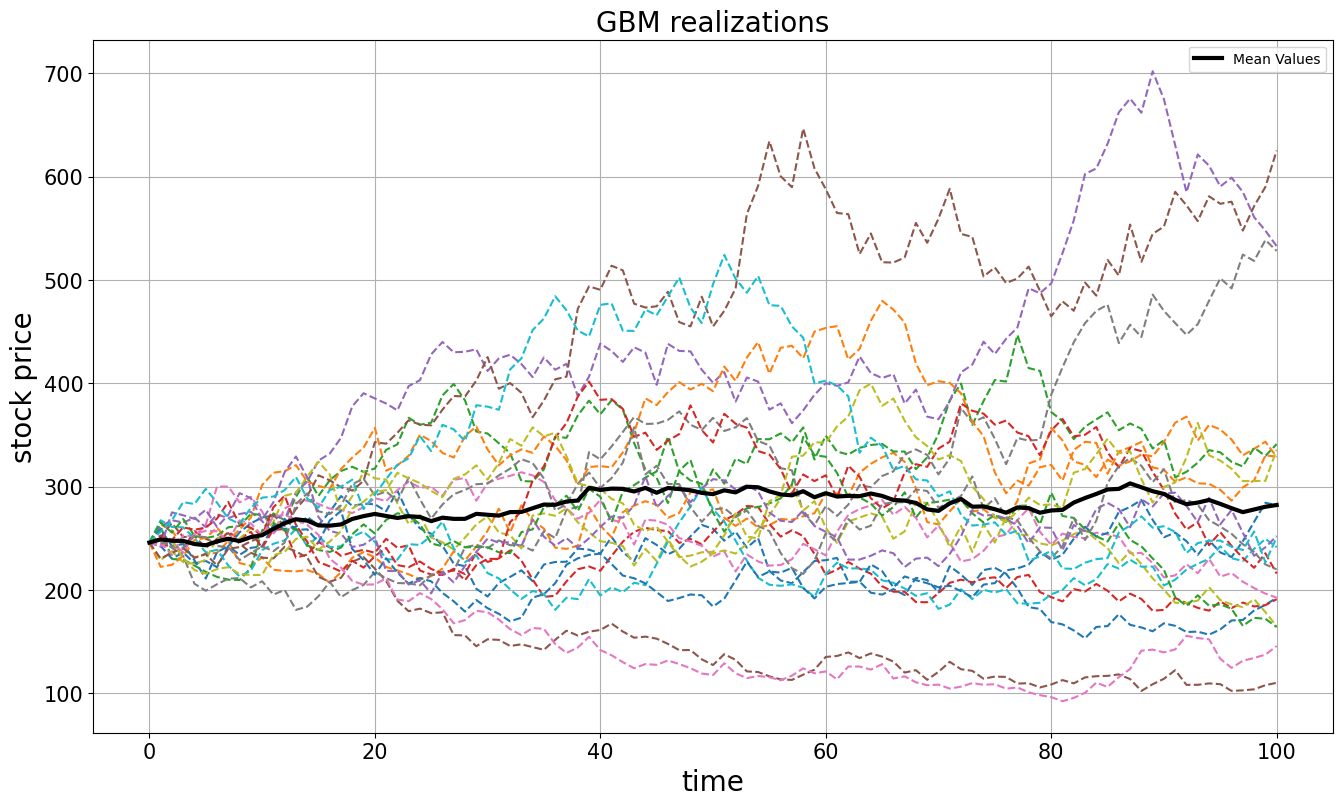

In [9]:
fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(trajectory.T, '--')
ax.plot(np.mean(trajectory, axis=0), label='Mean Values', c='k', lw=3)
ax.set_xlabel('time')
ax.set_ylabel('stock price')
ax.grid(True)
ax.set_title('GBM realizations')
ax.legend()

plt.show()

## Benchmarking Monte Carlo

### Convergence check

In [10]:
TICKER = "AAPL"

data = yf.download(TICKER, period="1y")["Close"]
log_returns = np.log(data / data.shift(1)).dropna()
r_free = 3.7e-2         # as of 05.04.2026
S0 = data.iloc[-1, 0]
sigma_year = log_returns.std()[TICKER] * np.sqrt(252) 

today = pd.Timestamp.today().normalize()
expiry = pd.Timestamp("2028-12-15")
trading_days = pd.bdate_range(today, expiry)  # business days only
n = len(trading_days)
T = n / 252

[*********************100%***********************]  1 of 1 completed


In [11]:
is_antithetic = [False, True]
N_SAMPS = np.round(np.geomspace(1e4, 1e8, num=50)).astype(int)

result_price = {
    'Naive': [],
    'Antithetic': []
}
result_variance = {
    'Naive': [],
    'Antithetic': []
}

In [12]:
mc = MonteCarlo_GBM(USE_NUMBA=False)
mc.load(S0=S0, K=210, sigma=sigma_year, r_free=r_free)

In [13]:
for i, n_samp in enumerate(list(N_SAMPS)):
    C, sigma = mc.direct_sampling(T, n_samp, antithetic=False)
    result_price['Naive'].append(C)
    result_variance['Naive'].append(sigma)

    C, sigma = mc.direct_sampling(T, n_samp, antithetic=True)
    result_price['Antithetic'].append(C)
    result_variance['Antithetic'].append(sigma)

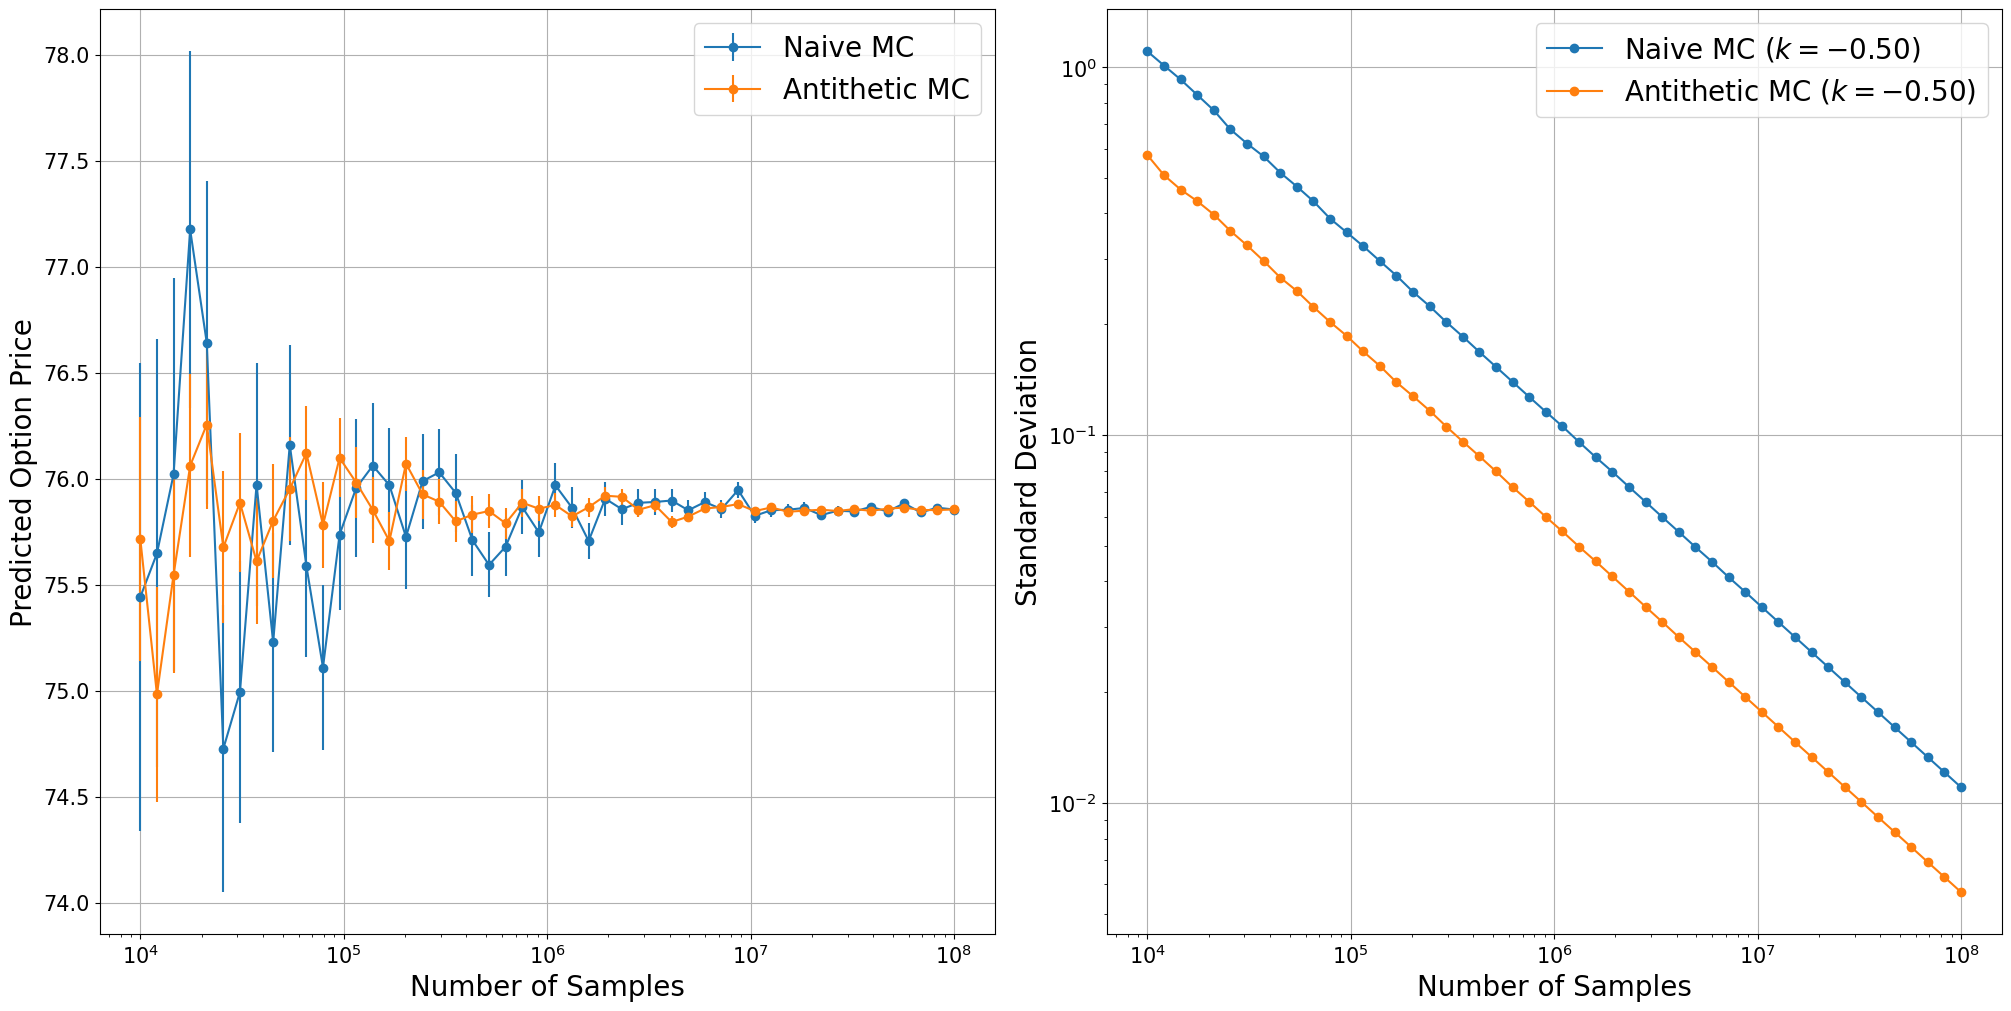

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10), layout='constrained')

axs[0].errorbar(N_SAMPS, result_price['Naive'], yerr=result_variance['Naive'], marker='o', label='Naive MC')
axs[0].errorbar(N_SAMPS, result_price['Antithetic'], yerr=result_variance['Antithetic'], marker='o', label='Antithetic MC')
axs[0].set_xlabel('Number of Samples')
axs[0].set_ylabel('Predicted Option Price')
axs[0].legend(fontsize=20)
axs[0].set_xscale('log')
axs[0].grid(True)

k1, _ = np.polyfit(np.log(N_SAMPS), np.log(result_variance['Naive']), deg=1)
k2, _ = np.polyfit(np.log(N_SAMPS), np.log(result_variance['Naive']), deg=1)
axs[1].loglog(N_SAMPS, result_variance['Naive'], '-o', label=r'Naive MC ($k={:.2f}$)'.format(k1))
axs[1].loglog(N_SAMPS, result_variance['Antithetic'], '-o', label=r'Antithetic MC ($k={:.2f}$)'.format(k2))
axs[1].set_xlabel('Number of Samples')
axs[1].set_ylabel('Standard Deviation')
axs[1].legend(fontsize=20)
axs[1].grid(True)

plt.show()

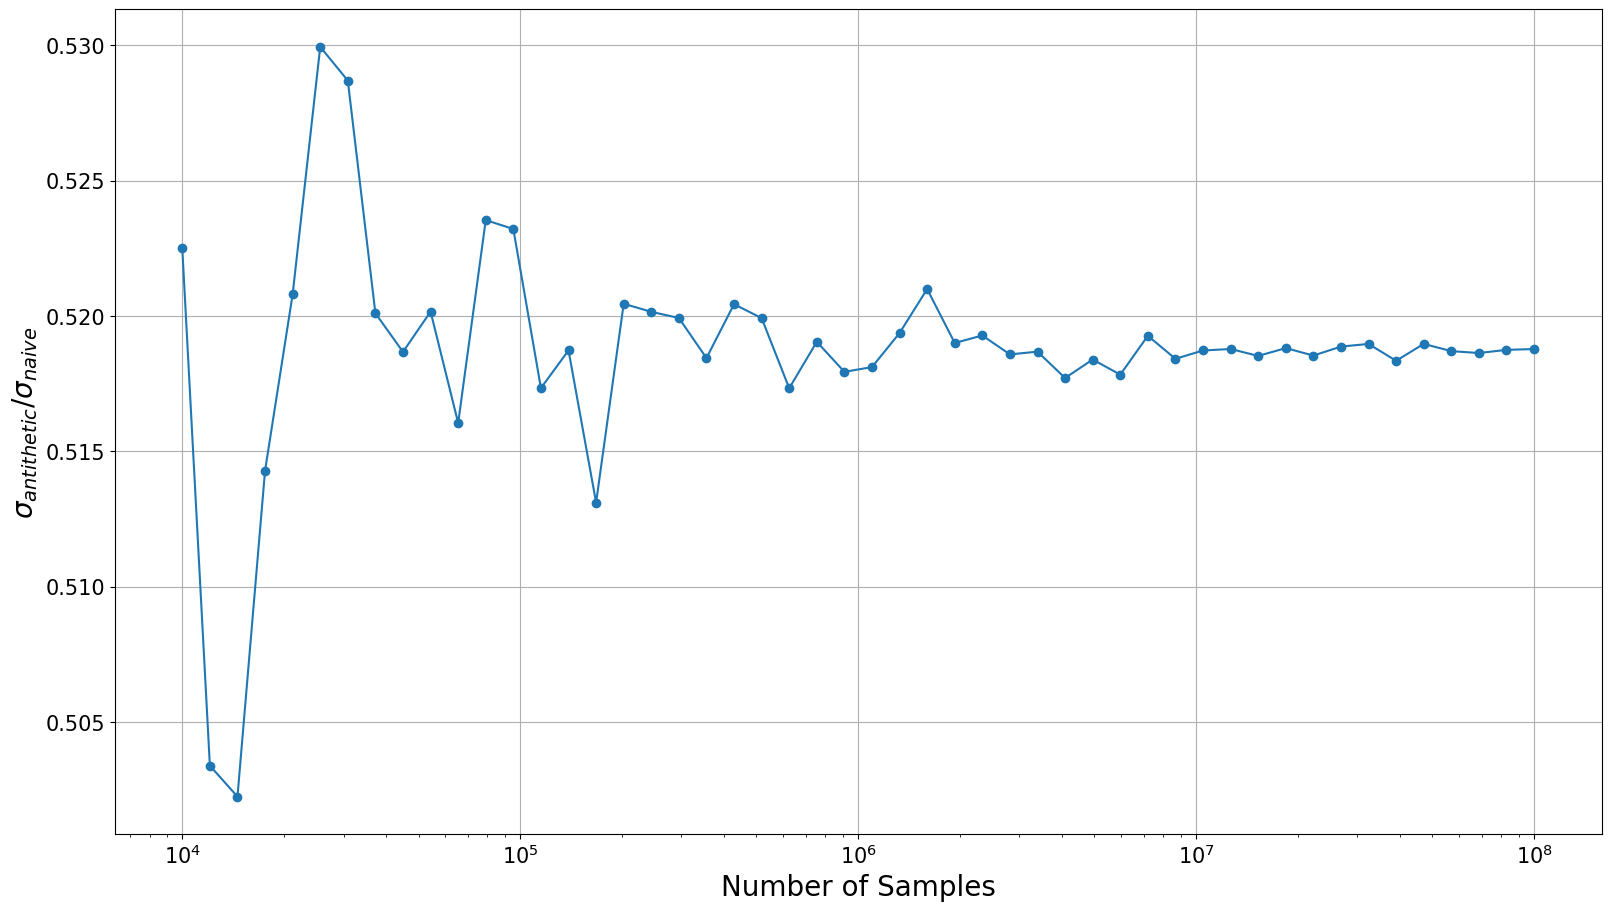

In [15]:
fig, ax = plt.subplots(figsize=(16, 9), layout='constrained')

ax.semilogx(N_SAMPS, np.asarray(result_variance['Antithetic'])/np.asarray(result_variance['Naive']), '-o')
ax.set_xlabel('Number of Samples')
ax.set_ylabel(r'$\sigma_{antithetic} / \sigma_{naive}$')
ax.grid(True)

plt.show()

- As expected, both methods converged to the same result when the number of samples is large enough ($\gtrsim 10^7$).
- The variation show decays as $\sim \frac{1}{\sqrt{N}}$ for both methods.
- Using antithetic technique, when the number of samples is unchanged, the variation can be scaled down by a constant factor (around $2$).

### Comparison with B-S equation and real market data

**(!)Note: The following functions within this subsection about fetching data and plotting are written assisted by Claude Code, as it usually creates cleaner visualizations.**

1. Select call options from 3 different companies.
2. For each company, select 5 different expiry dates with the same strike, compare the MC-predicted, analytic-solution-predicted and the actual prices from the internet.
3. For each company, select 5 different strikes on the same expiry date, compare the MC-predicted, analytic-solution-predicted and the actual prices from the internet.

In [16]:
# ── Get stock data from 3 companies ──────────────────────────────────────────
TICKERS = ["AAPL", "GOOGL", "CRSP"]     # note that CRSP represents a mid size biotech company
r_free  = 3.7e-2          # risk-free rate (as of 05.04.2026)
today   = pd.Timestamp.today().normalize()

company_params = {}
for ticker in TICKERS:
    raw = yf.download(ticker, period="1y", auto_adjust=True, progress=False)["Close"]
    log_return = np.log(raw / raw.shift(1)).dropna()
    S0 = raw.iloc[-1, 0]
    sigma_year = log_return.std()[ticker] * np.sqrt(252)
    company_params[ticker] = {"S0": S0, "sigma": sigma_year}
    print(f"{ticker:5s}  S0={S0:.2f}  σ_annual={sigma_year:.4f}")


AAPL   S0=245.88  σ_annual=0.2905
GOOGL  S0=299.37  σ_annual=0.3003
CRSP   S0=48.01  σ_annual=0.6301


#### Benchmark — 5 expiry dates, same strike

In [48]:
N_MC = int(1e6)   # number of samples for MC
STRIKES = [260, 295, 50]

def pick_expiries(all_expiries, n=3):
    """Pick n expiry dates spread across the available range."""
    future = [e for e in all_expiries if pd.Timestamp(e) > today]
    if len(future) < n:
        return future
    idx = np.linspace(0, len(future) - 1, n, dtype=int)
    return [future[i] for i in idx]

def T_from_expiry(expiry_str):
    bdays = pd.bdate_range(today, pd.Timestamp(expiry_str))
    return len(bdays) / 252

def get_market_price(chain_calls, strike):
    row = chain_calls[chain_calls["strike"] == strike]
    if row.empty:
        return np.nan, np.nan
    bid, ask, last = row["bid"].iloc[0], row["ask"].iloc[0], row["lastPrice"].iloc[0]
    mid = (bid + ask) / 2 if bid > 0 and ask > 0 else np.nan
    return last, mid

# ── Run Benchmark ───────────────────────────────────────────────────────────
results_A = {}

for i, ticker in enumerate(TICKERS):
    S0 = company_params[ticker]["S0"]
    sigma = company_params[ticker]["sigma"]
    stock = yf.Ticker(ticker)

    expiries = pick_expiries(stock.options, n=5)

    # Fetch chains
    # chains = {e: stock.option_chain(e).calls for e in expiries}
    # strike = STRIKES[i]
    chains = {e: stock.option_chain(e).calls for e in expiries}
    common_strikes = set(chains[expiries[0]]["strike"])
    for e in expiries[1:]:
        common_strikes &= set(chains[e]["strike"])
    strike = min(common_strikes, key=lambda k: abs(k - S0))

    rows = []
    for e in expiries:
        T = T_from_expiry(e)
        pricer = MonteCarlo_GBM(USE_NUMBA = False)
        pricer.load(S0, strike, sigma, r_free)

        mc_price, mc_se = pricer.direct_sampling(T, n_samples=N_MC)
        bs_price = pricer.analytical_solution(T)
        mkt_last, mkt_mid = get_market_price(chains[e], strike)

        rows.append({
            "Expiry": e,
            "Strike": strike,
            "T (yr)": round(T, 3),
            "MC Price": round(mc_price, 3),
            "MC ±2σ": round(2 * mc_se, 3),
            "BS Price": round(bs_price, 3),
            "Mkt Last": round(mkt_last, 3) if not np.isnan(mkt_last) else np.nan,
            "Mkt Mid": round(mkt_mid, 3)  if not np.isnan(mkt_mid)  else np.nan,
        })

    results_A[ticker] = pd.DataFrame(rows)
    print(f"\n{'='*60}")
    print(f" {ticker} (S0={S0:.2f}, K={strike}, σ={sigma:.4f})")
    print(results_A[ticker].to_string(index=False))



 AAPL (S0=245.88, K=250.0, σ=0.2905)
    Expiry  Strike  T (yr)  MC Price  MC ±2σ  BS Price  Mkt Last  Mkt Mid
2026-04-08   250.0   0.008     1.031   0.003     1.029      1.11    1.130
2026-04-24   250.0   0.056     5.112   0.010     5.113      5.35    5.375
2026-07-17   250.0   0.294    14.767   0.027    14.770     15.45   15.350
2027-01-15   250.0   0.810    27.065   0.051    27.056     28.50   28.475
2028-12-15   250.0   2.794    56.134   0.117    56.123     57.76   57.800

 GOOGL (S0=299.37, K=300.0, σ=0.3003)
    Expiry  Strike  T (yr)  MC Price  MC ±2σ  BS Price  Mkt Last  Mkt Mid
2026-04-08   300.0   0.008     2.933   0.005     2.934      3.00    2.945
2026-04-24   300.0   0.056     8.432   0.014     8.444      9.75    9.750
2026-07-17   300.0   0.294    20.681   0.035    20.660     23.39   23.925
2027-01-15   300.0   0.810    35.960   0.065    36.003     41.80   42.000
2028-12-15   300.0   2.794    71.964   0.150    71.993     84.43   83.575

 CRSP (S0=48.01, K=50.0, σ=0.6301)

#### Benchmark — 5 strikes, same expiry date

In [50]:
def pick_strikes(chain_calls, S0, n=3):
    """Pick n strikes: one higher, one near (roughly), one lower (roughly equal spacing around S0)."""
    strikes = sorted(chain_calls["strike"].unique())
    idx = min(range(len(strikes)), key=lambda i: abs(strikes[i] - S0))
    # aim for one strike below, one around the current stock price
    step = max(1, int(len(strikes) * 0.15))
    indices = sorted(set([
        max(0, idx - step),
        idx,
        min(len(strikes) - 1, idx + step),
    ]))
    # ensure we get exactly n distinct strikes
    while len(indices) < n and len(strikes) > len(indices):
        for adj in [1, -1, 2, -2]:
            candidate = idx + adj * step
            if 0 <= candidate < len(strikes) and candidate not in indices:
                indices.append(candidate)
                indices = sorted(set(indices))
            if len(indices) == n:
                break
    return [strikes[i] for i in indices[:n]]

# ── Run Benchmark B ───────────────────────────────────────────────────────────
results_B = {}

for ticker in TICKERS:
    S0    = company_params[ticker]["S0"]
    sigma = company_params[ticker]["sigma"]
    stock = yf.Ticker(ticker)

    # Pick a mid-range expiry (different from Benchmark A's selection to add variety)
    future_expiries = [e for e in stock.options if pd.Timestamp(e) > today]
    expiry = future_expiries[len(future_expiries) // 3]   # roughly 1/3 into the future
    T      = T_from_expiry(expiry)

    chain_calls = stock.option_chain(expiry).calls
    strikes     = pick_strikes(chain_calls, S0, n=3)

    rows = []
    for K in strikes:
        pricer = MonteCarlo_GBM(USE_NUMBA = False)
        pricer.load(S0, K, sigma, r_free)

        mc_price, mc_se = pricer.direct_sampling(T, n_samples=N_MC)
        bs_price        = pricer.analytical_solution(T)
        mkt_last, mkt_mid = get_market_price(chain_calls, K)

        moneyness = "ATM" if abs(K - S0) / S0 < 0.03 else ("ITM" if K < S0 else "OTM")
        rows.append({
            "Strike": K,
            "Moneyness": moneyness,
            "T (yr)": round(T, 3),
            "MC Price": round(mc_price, 3),
            "MC ±2σ": round(2 * mc_se, 3),
            "BS Price": round(bs_price, 3),
            "Mkt Last": round(mkt_last, 3) if not np.isnan(mkt_last) else np.nan,
            "Mkt Mid": round(mkt_mid, 3)  if not np.isnan(mkt_mid)  else np.nan,
        })

    results_B[ticker] = pd.DataFrame(rows)
    print(f"\n{'='*60}")
    print(f"  {ticker}  (S0={S0:.2f}, expiry={expiry}, σ={sigma:.4f})")
    print(results_B[ticker].to_string(index=False))



  AAPL  (S0=245.88, expiry=2026-05-08, σ=0.2905)
 Strike Moneyness  T (yr)  MC Price  MC ±2σ  BS Price  Mkt Last  Mkt Mid
  225.0       ITM   0.095    23.324   0.009    23.329     31.65   25.875
  245.0       ATM   0.095     9.650   0.015     9.658     11.47   11.300
  265.0       OTM   0.095     2.773   0.010     2.763      2.90    2.915

  GOOGL  (S0=299.37, expiry=2026-05-08, σ=0.3003)
 Strike Moneyness  T (yr)  MC Price  MC ±2σ  BS Price  Mkt Last  Mkt Mid
  280.0       ITM   0.095    23.809   0.014    23.806     27.50   26.975
  300.0       ATM   0.095    11.262   0.018    11.269     14.35   14.350
  320.0       OTM   0.095     4.210   0.014     4.220      5.61    5.900

  CRSP  (S0=48.01, expiry=2026-05-08, σ=0.6301)
 Strike Moneyness  T (yr)  MC Price  MC ±2σ  BS Price  Mkt Last  Mkt Mid
   45.0       ITM   0.095     5.394   0.007     5.398      4.85    5.850
   48.0       ATM   0.095     3.799   0.007     3.802      3.90    4.400
   50.0       OTM   0.095     2.947   0.007    

#### Visualisation — MC vs BS vs Market

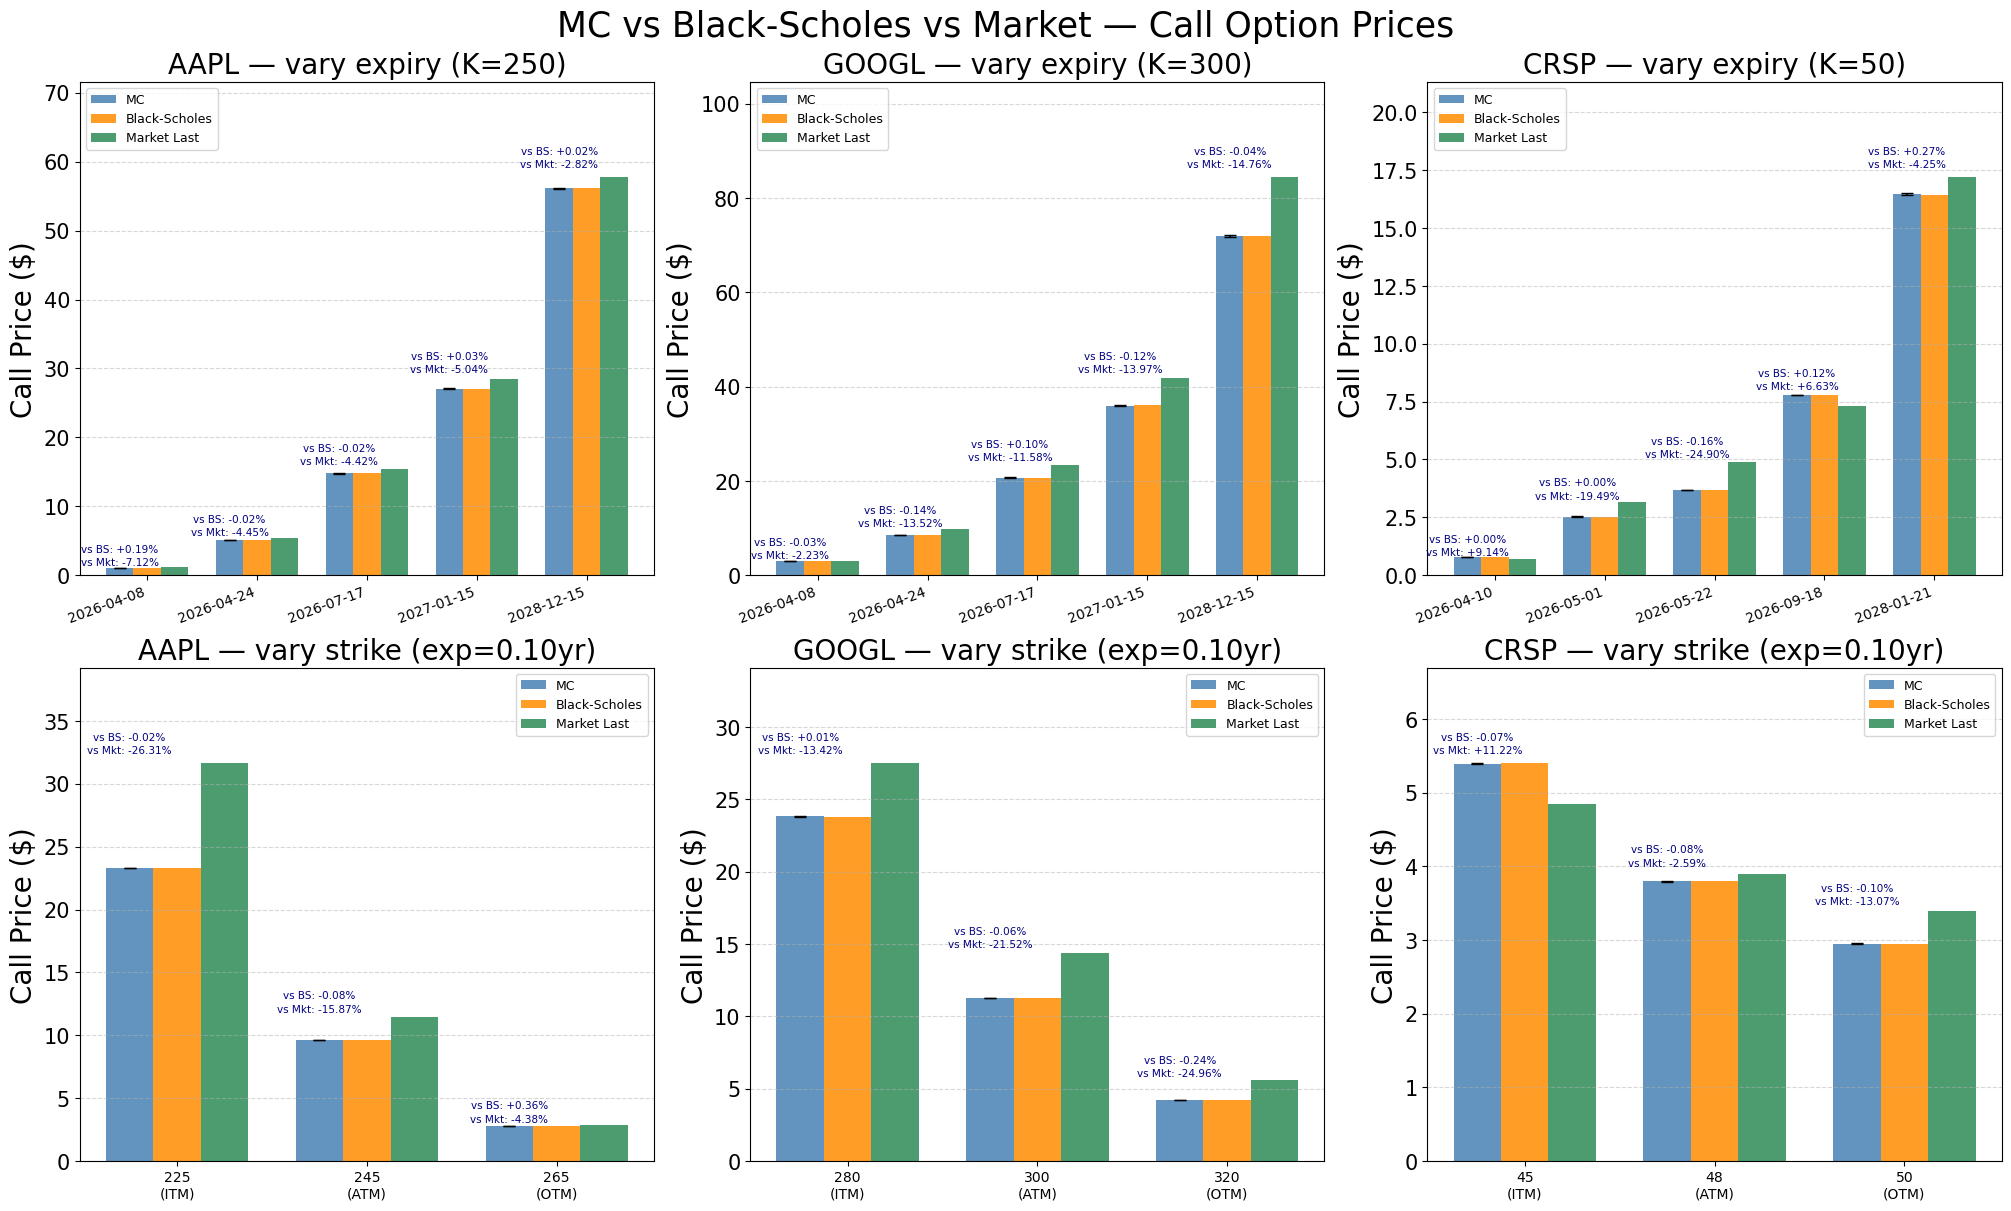

In [51]:
def annotate_rel_diff(ax, x_positions, df, bar_width, price_col="MC Price"):
    """
    Above each group of bars, annotate two relative differences:
        (MC - BS)  / BS
        (MC - Mkt) / Mkt
    Text is placed just above the tallest bar in each group.
    """
    for xi, (_, row) in zip(x_positions, df.iterrows()):
        mc  = row["MC Price"]
        bs  = row["BS Price"]
        mkt = row["Mkt Last"]

        # top of the tallest bar in this group
        candidates = [mc, bs]
        if not np.isnan(mkt):
            candidates.append(mkt)
        y_top = max(candidates) * 1.02      # 2 % headroom above tallest bar

        lines = []
        if bs > 0:
            rel_bs = (mc - bs) / bs * 100
            lines.append(f"vs BS: {rel_bs:+.2f}%")
        if not np.isnan(mkt) and mkt > 0:
            rel_mkt = (mc - mkt) / mkt * 100
            lines.append(f"vs Mkt: {rel_mkt:+.2f}%")

        if lines:
            ax.text(xi - bar_width, y_top, "\n".join(lines),
                    ha="center", va="bottom", fontsize=7.5,
                    color="navy", linespacing=1.4)


fig, axes = plt.subplots(2, 3, figsize=(20, 12), layout='constrained')
fig.suptitle("MC vs Black-Scholes vs Market — Call Option Prices", fontsize=25)

for col, ticker in enumerate(TICKERS):
    w = 0.25

    # ── Benchmark A: vary expiry ──────────────────────────────────────────────
    ax = axes[0, col]
    df = results_A[ticker]
    x  = np.arange(len(df))

    ax.bar(x - w, df["MC Price"],  w, label="MC",           color="steelblue",  alpha=0.85)
    ax.bar(x,     df["BS Price"],  w, label="Black-Scholes", color="darkorange", alpha=0.85)
    ax.bar(x + w, df["Mkt Last"],  w, label="Market Last",   color="seagreen",   alpha=0.85)
    ax.errorbar(x - w, df["MC Price"], yerr=df["MC ±2σ"],
                fmt="none", color="black", capsize=4, linewidth=1.2)

    annotate_rel_diff(ax, x, df, w)

    ax.set_xticks(x)
    ax.set_xticklabels(df["Expiry"], rotation=20, ha="right", fontsize=10)
    ax.set_title(f"{ticker} — vary expiry (K={df['Strike'].iloc[0]:.0f})")
    ax.set_ylabel("Call Price ($)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    # extra headroom for annotations
    ymax = ax.get_ylim()[1]
    ax.set_ylim(top=ymax * 1.18)

    # ── Benchmark B: vary strike ──────────────────────────────────────────────
    ax = axes[1, col]
    df = results_B[ticker]
    x  = np.arange(len(df))

    ax.bar(x - w, df["MC Price"],  w, label="MC",            color="steelblue",  alpha=0.85)
    ax.bar(x,     df["BS Price"],  w, label="Black-Scholes",  color="darkorange", alpha=0.85)
    ax.bar(x + w, df["Mkt Last"],  w, label="Market Last",    color="seagreen",   alpha=0.85)
    ax.errorbar(x - w, df["MC Price"], yerr=df["MC ±2σ"],
                fmt="none", color="black", capsize=4, linewidth=1.2)

    annotate_rel_diff(ax, x, df, w)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{row.Strike:.0f}\n({row.Moneyness})" for row in df.itertuples()],
        fontsize=10)
    ax.set_title(f"{ticker} — vary strike (exp={df['T (yr)'].iloc[0]:.2f}yr)")
    ax.set_ylabel("Call Price ($)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ymax = ax.get_ylim()[1]
    ax.set_ylim(top=ymax * 1.18)

plt.show()


1. Across different companies
    - The model roughly catches the price of the option for different companies.
2. For the same company, same strike, different expiry date
    - For the big companies (Apple, Google), the model has the tendency to underestimate the prices for longer expiry dates. 
    - For small company, the fluctuation seems larger, and harder to see the trend.
3. For the same company, same expiry date, different strike prices
    - From the three examples, it is hard to say if there is any systematic over/underestimation.

### Numba acceleration

In [20]:
import time

In [21]:
TICKER = "AAPL"

data = yf.download(TICKER, period="1y")["Close"]
log_returns = np.log(data / data.shift(1)).dropna()
r_free = 3.7e-2         # as of 05.04.2026
S0 = data.iloc[-1, 0]
sigma_year = log_returns.std()[TICKER] * np.sqrt(252) 

today = pd.Timestamp.today().normalize()
expiry = pd.Timestamp("2028-12-15")
trading_days = pd.bdate_range(today, expiry)  # business days only
n = len(trading_days)
T = n / 252

[*********************100%***********************]  1 of 1 completed


#### direct sampling

In [29]:
NUM_SAMPS = np.round(np.geomspace(100000, 100000000, num=10)).astype(int) 
NUM_TRIALS = 1

In [30]:
pricer_without_numba = MonteCarlo_GBM(USE_NUMBA=False)
pricer_without_numba.load(S0=S0, K=210, sigma=sigma_year, r_free=r_free)
time_consumption = []

for _ in range(NUM_TRIALS):
    for n_samp in np.nditer(NUM_SAMPS):
        start = time.time()
        _, _ = pricer_without_numba.direct_sampling(T, n_samples=n_samp, antithetic=True)
        end = time.time()
        time_consumption.append(end - start)
        print("Time Consumption without numba: ", '{:.3f} s'.format(end-start))

# print("Average Time Consumption without numba: ", '{:.3f} s'.format(time_consumption/NUM_TRIALS))

Time Consumption without numba:  0.006 s
Time Consumption without numba:  0.012 s
Time Consumption without numba:  0.020 s
Time Consumption without numba:  0.033 s
Time Consumption without numba:  0.064 s
Time Consumption without numba:  0.134 s
Time Consumption without numba:  0.283 s
Time Consumption without numba:  0.793 s
Time Consumption without numba:  1.683 s
Time Consumption without numba:  5.144 s


In [31]:
pricer_with_numba = MonteCarlo_GBM(USE_NUMBA=True)
pricer_with_numba.load(S0=S0, K=210, sigma=sigma_year, r_free=r_free)
time_consumption_with_numba = []

for _ in range(NUM_TRIALS):
    for n_samp in np.nditer(NUM_SAMPS):
        start = time.time()
        _, _ = pricer_without_numba.direct_sampling(T, n_samples=n_samp, antithetic=True)
        end = time.time()
        time_consumption_with_numba.append(end - start)
        print("Time Consumption with numba: ", '{:.3f} s'.format(end-start))

# print("Average Time Consumption with numba: ", '{:.3f} s'.format(time_consumption/NUM_TRIALS))

Time Consumption with numba:  0.006 s
Time Consumption with numba:  0.009 s
Time Consumption with numba:  0.017 s
Time Consumption with numba:  0.032 s
Time Consumption with numba:  0.064 s
Time Consumption with numba:  0.133 s
Time Consumption with numba:  0.285 s
Time Consumption with numba:  0.670 s
Time Consumption with numba:  1.484 s
Time Consumption with numba:  4.533 s


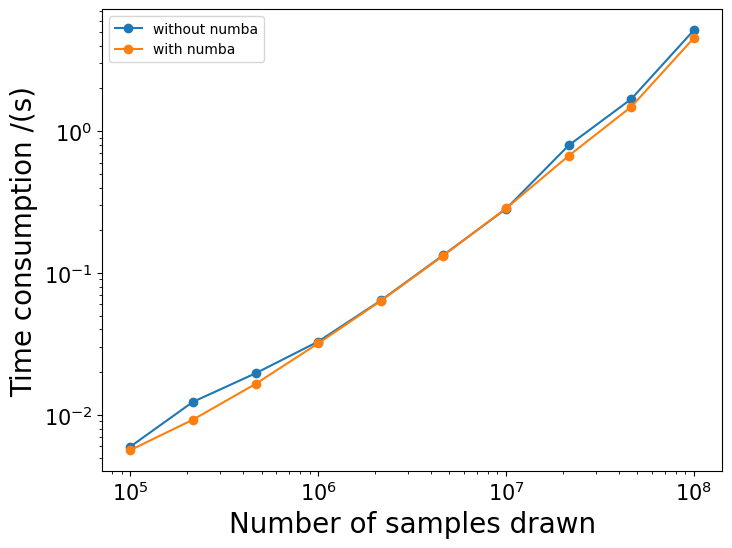

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.loglog(NUM_SAMPS, time_consumption, '-o', label='without numba')
ax.loglog(NUM_SAMPS, time_consumption_with_numba, '-o', label='with numba')

ax.set_xlabel('Number of samples drawn')
ax.set_ylabel('Time consumption /(s)')
ax.legend()

plt.show()

#### Monte Carlo path sampling

In [38]:
NUM_SAMPS = np.round(np.geomspace(1000, 10000, num=10)).astype(int) 
NUM_TRIALS = 1

In [39]:
pricer_without_numba = MonteCarlo_GBM(USE_NUMBA=False)
pricer_without_numba.load(S0=S0, K=210, sigma=sigma_year, r_free=r_free)
time_consumption = []

for _ in range(NUM_TRIALS):
    for n_samp in np.nditer(NUM_SAMPS):
        start = time.time()
        _, _ = pricer_without_numba.mc_simulation(T, n_samples=n_samp, n_steps=1000)
        end = time.time()
        time_consumption.append(end - start)
        print("Time Consumption without numba: ", '{:.3f} s'.format(end-start))

# print("Average Time Consumption without numba: ", '{:.3f} s'.format(time_consumption/NUM_TRIALS))

Time Consumption without numba:  1.125 s
Time Consumption without numba:  1.431 s
Time Consumption without numba:  1.827 s
Time Consumption without numba:  2.297 s
Time Consumption without numba:  2.967 s
Time Consumption without numba:  3.866 s
Time Consumption without numba:  5.072 s
Time Consumption without numba:  6.656 s
Time Consumption without numba:  8.591 s
Time Consumption without numba:  10.735 s


In [41]:
pricer_with_numba = MonteCarlo_GBM(USE_NUMBA=True)
pricer_with_numba.load(S0=S0, K=210, sigma=sigma_year, r_free=r_free)
time_consumption_with_numba = []

for _ in range(NUM_TRIALS):
    for n_samp in np.nditer(NUM_SAMPS):
        start = time.time()
        _, _ = pricer_with_numba.mc_simulation(T, n_samples=int(n_samp), n_steps=1000)
        end = time.time()
        time_consumption_with_numba.append(end - start)
        print("Time Consumption without numba: ", '{:.3f} s'.format(end-start))

Time Consumption without numba:  0.214 s
Time Consumption without numba:  0.025 s
Time Consumption without numba:  0.032 s
Time Consumption without numba:  0.041 s
Time Consumption without numba:  0.053 s
Time Consumption without numba:  0.068 s
Time Consumption without numba:  0.088 s
Time Consumption without numba:  0.115 s
Time Consumption without numba:  0.147 s
Time Consumption without numba:  0.195 s


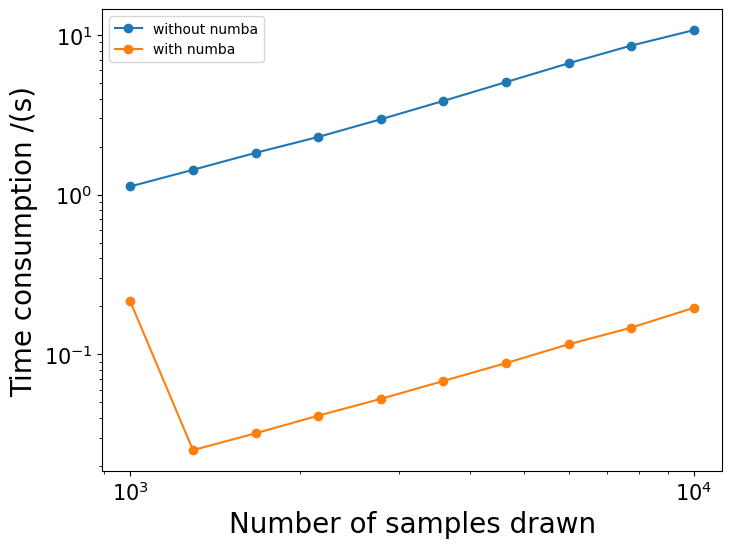

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.loglog(NUM_SAMPS, time_consumption, '-o', label='without numba')
ax.loglog(NUM_SAMPS, time_consumption_with_numba, '-o', label='with numba')

ax.set_xlabel('Number of samples drawn')
ax.set_ylabel('Time consumption /(s)')
ax.legend()

plt.show()

**So when `for`-loop is involved in the Monte Carlo simulations, *numba* will provide huge acceleration as expected. For more complicated models where there is no exact solution to the stochastic differential equation (therefore time discretization and simulation is needed), *numba* is a good choice.**

Note that the first point with numba is high because of the compilation time.

# Development from simple GBM model

## Check the validity of the assumption used in BS

### Apple

In [11]:
data = yf.download("AAPL", period="1y")["Close"]

[*********************100%***********************]  1 of 1 completed


In [18]:
log_returns = np.log(data / data.shift(1)).dropna().to_numpy()
log_returns_segment = np.array_split(log_returns, 20)
sigma_segment = np.empty(20)
for i in range(len(log_returns_segment)):
    sigma_segment[i] = np.std(log_returns_segment[i])

Text(0.5, 1.0, 'histogram of log return in 1 yr')

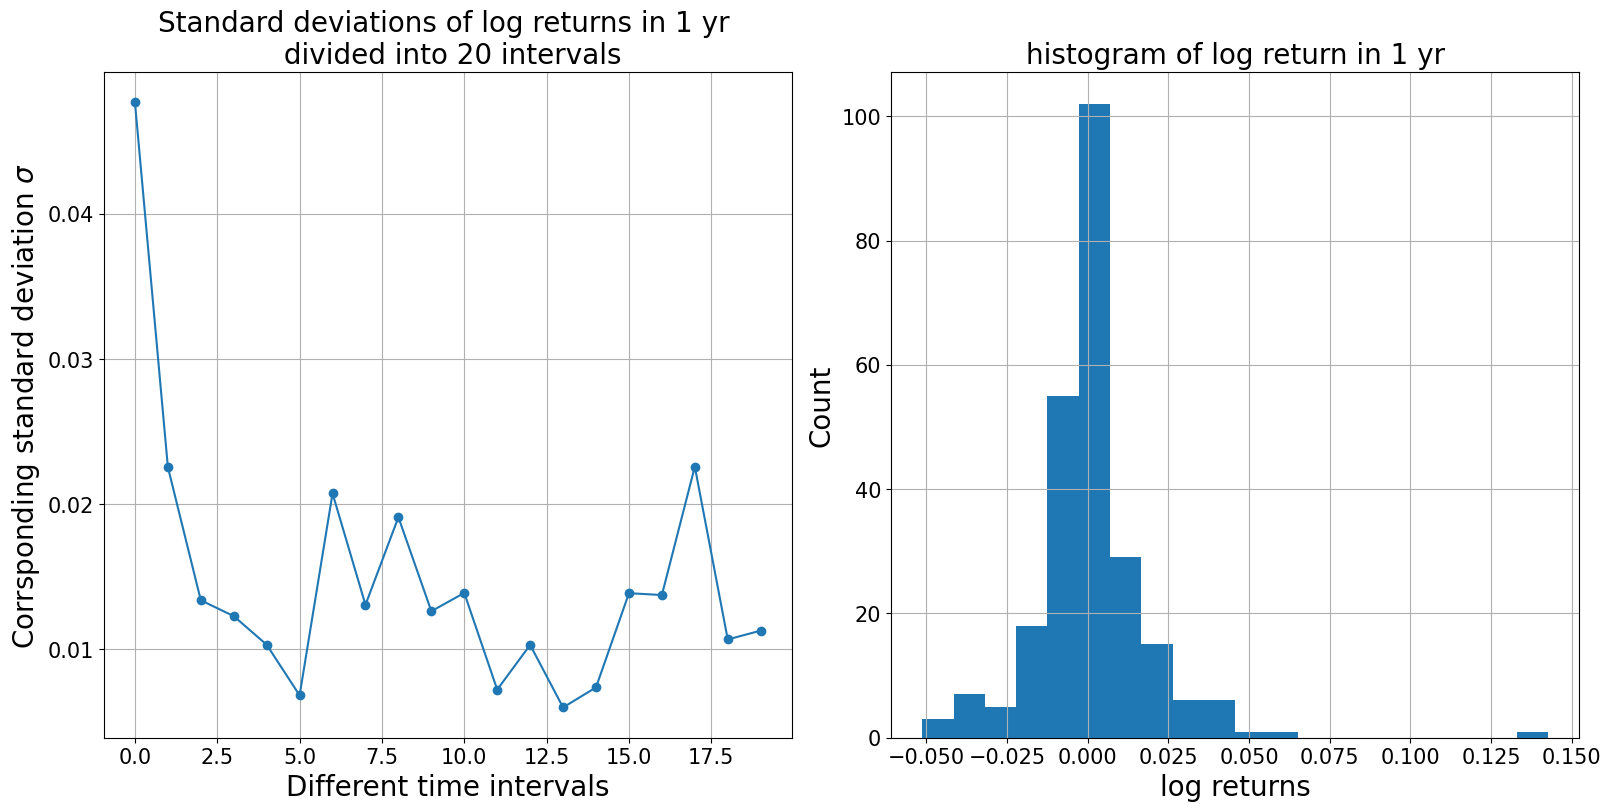

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8), layout='constrained')

axs[0].plot(sigma_segment, '-o')
axs[0].grid(True)
axs[0].set_xlabel('Different time intervals')
axs[0].set_ylabel(r'Corrsponding standard deviation $\sigma$')
axs[0].set_title('Standard deviations of log returns in 1 yr \n divided into 20 intervals')

axs[1].hist(log_returns, align='mid', bins=20)
axs[1].set_xlabel('log returns')
axs[1].set_ylabel('Count')
axs[1].grid(True)
axs[1].set_title('histogram of log return in 1 yr')

### CRISPR Therapeutics AG

In [28]:
data = yf.download("CRSP", period="1y")["Close"]

[*********************100%***********************]  1 of 1 completed


In [29]:
log_returns = np.log(data / data.shift(1)).dropna().to_numpy()
log_returns_segment = np.array_split(log_returns, 20)
sigma_segment = np.empty(20)
for i in range(len(log_returns_segment)):
    sigma_segment[i] = np.std(log_returns_segment[i])

Text(0.5, 1.0, 'histogram of log return in 1 yr')

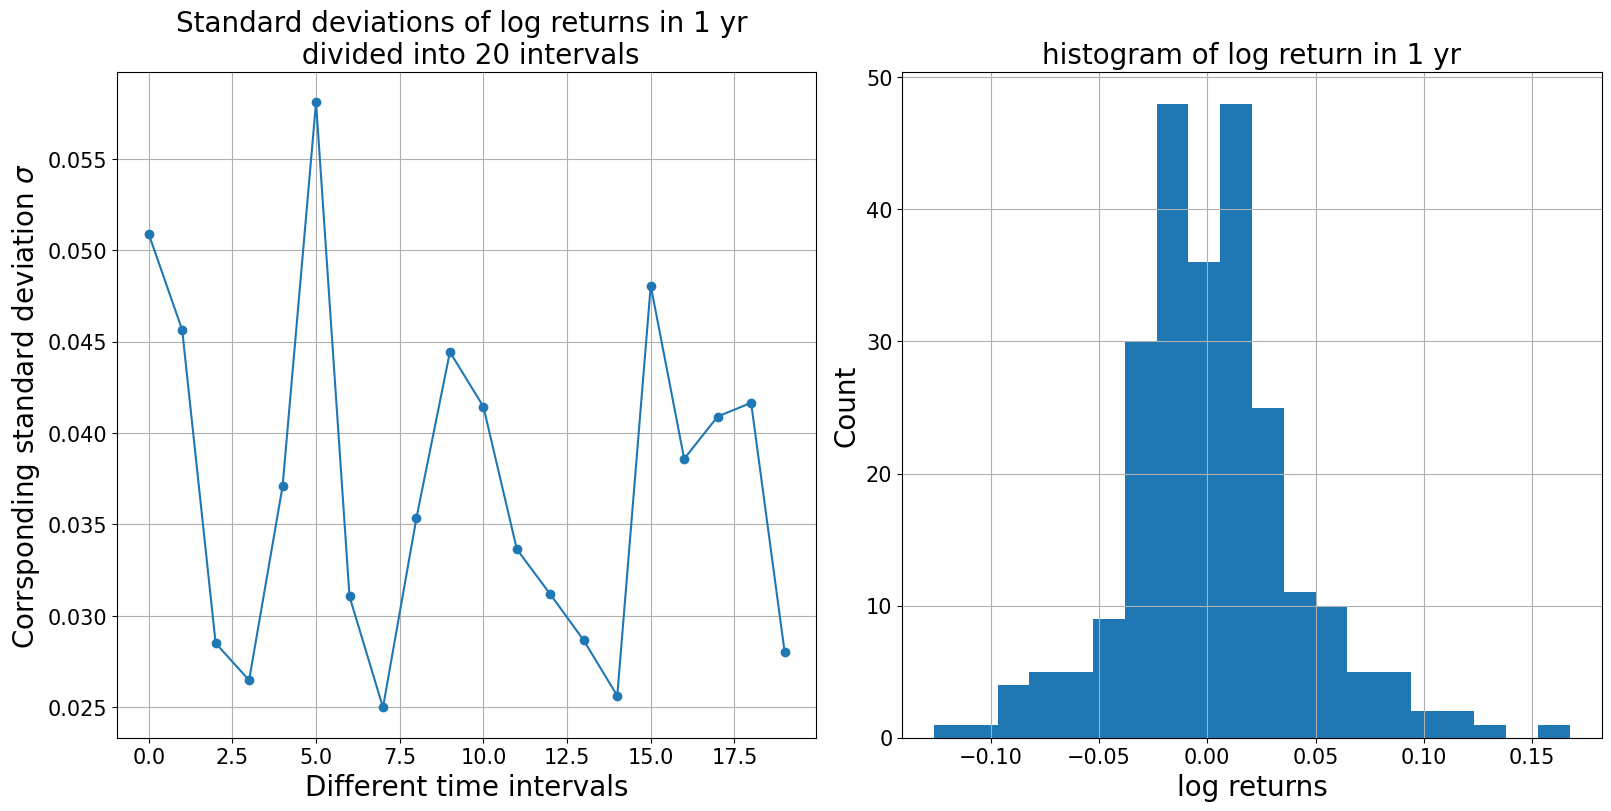

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8), layout='constrained')

axs[0].plot(sigma_segment, '-o')
axs[0].grid(True)
axs[0].set_xlabel('Different time intervals')
axs[0].set_ylabel(r'Corrsponding standard deviation $\sigma$')
axs[0].set_title('Standard deviations of log returns in 1 yr \n divided into 20 intervals')

axs[1].hist(log_returns, align='mid', bins=20)
axs[1].set_xlabel('log returns')
axs[1].set_ylabel('Count')
axs[1].grid(True)
axs[1].set_title('histogram of log return in 1 yr')

- Clearly, the two assumptions in usual BS calculation actually do not hold very firmly.
    1. The standard deviation $\sigma$ of the return is not a constant.
    2. The returns are subject to "fat tail", not entirely i.i.d. Gaussian distribution.

- One improvement may be incorporating the fluctuating variation into the model.

## Illustration - Heston Model

In [10]:
data = yf.download("AAPL", period="1y")["Close"]

[*********************100%***********************]  1 of 1 completed


In [11]:
log_returns = np.log(data / data.shift(1)).dropna()
r_free = 3.7e-2         # as of 05.04.2026
S0 = data.iloc[-1, 0]
# sigma_year = log_returns.std()['AAPL'] * np.sqrt(252) 

today = pd.Timestamp.today().normalize()
expiry = pd.Timestamp("2028-12-15")

# Count trading days using the US trading calendar
trading_days = pd.bdate_range(today, expiry)  # business days only
n = len(trading_days)
T = n / 252

In [12]:
mc = MonteCarlo_Heston(USE_NUMBA=True)
mc.load(S0=S0, K=210, r_free=r_free, v0=0.04, kappa=2, theta=0.04, xi=0.3, rho=-0.5)

In [15]:
S, V = mc.mc_demo(T, n_samples=20, n_steps=1000)

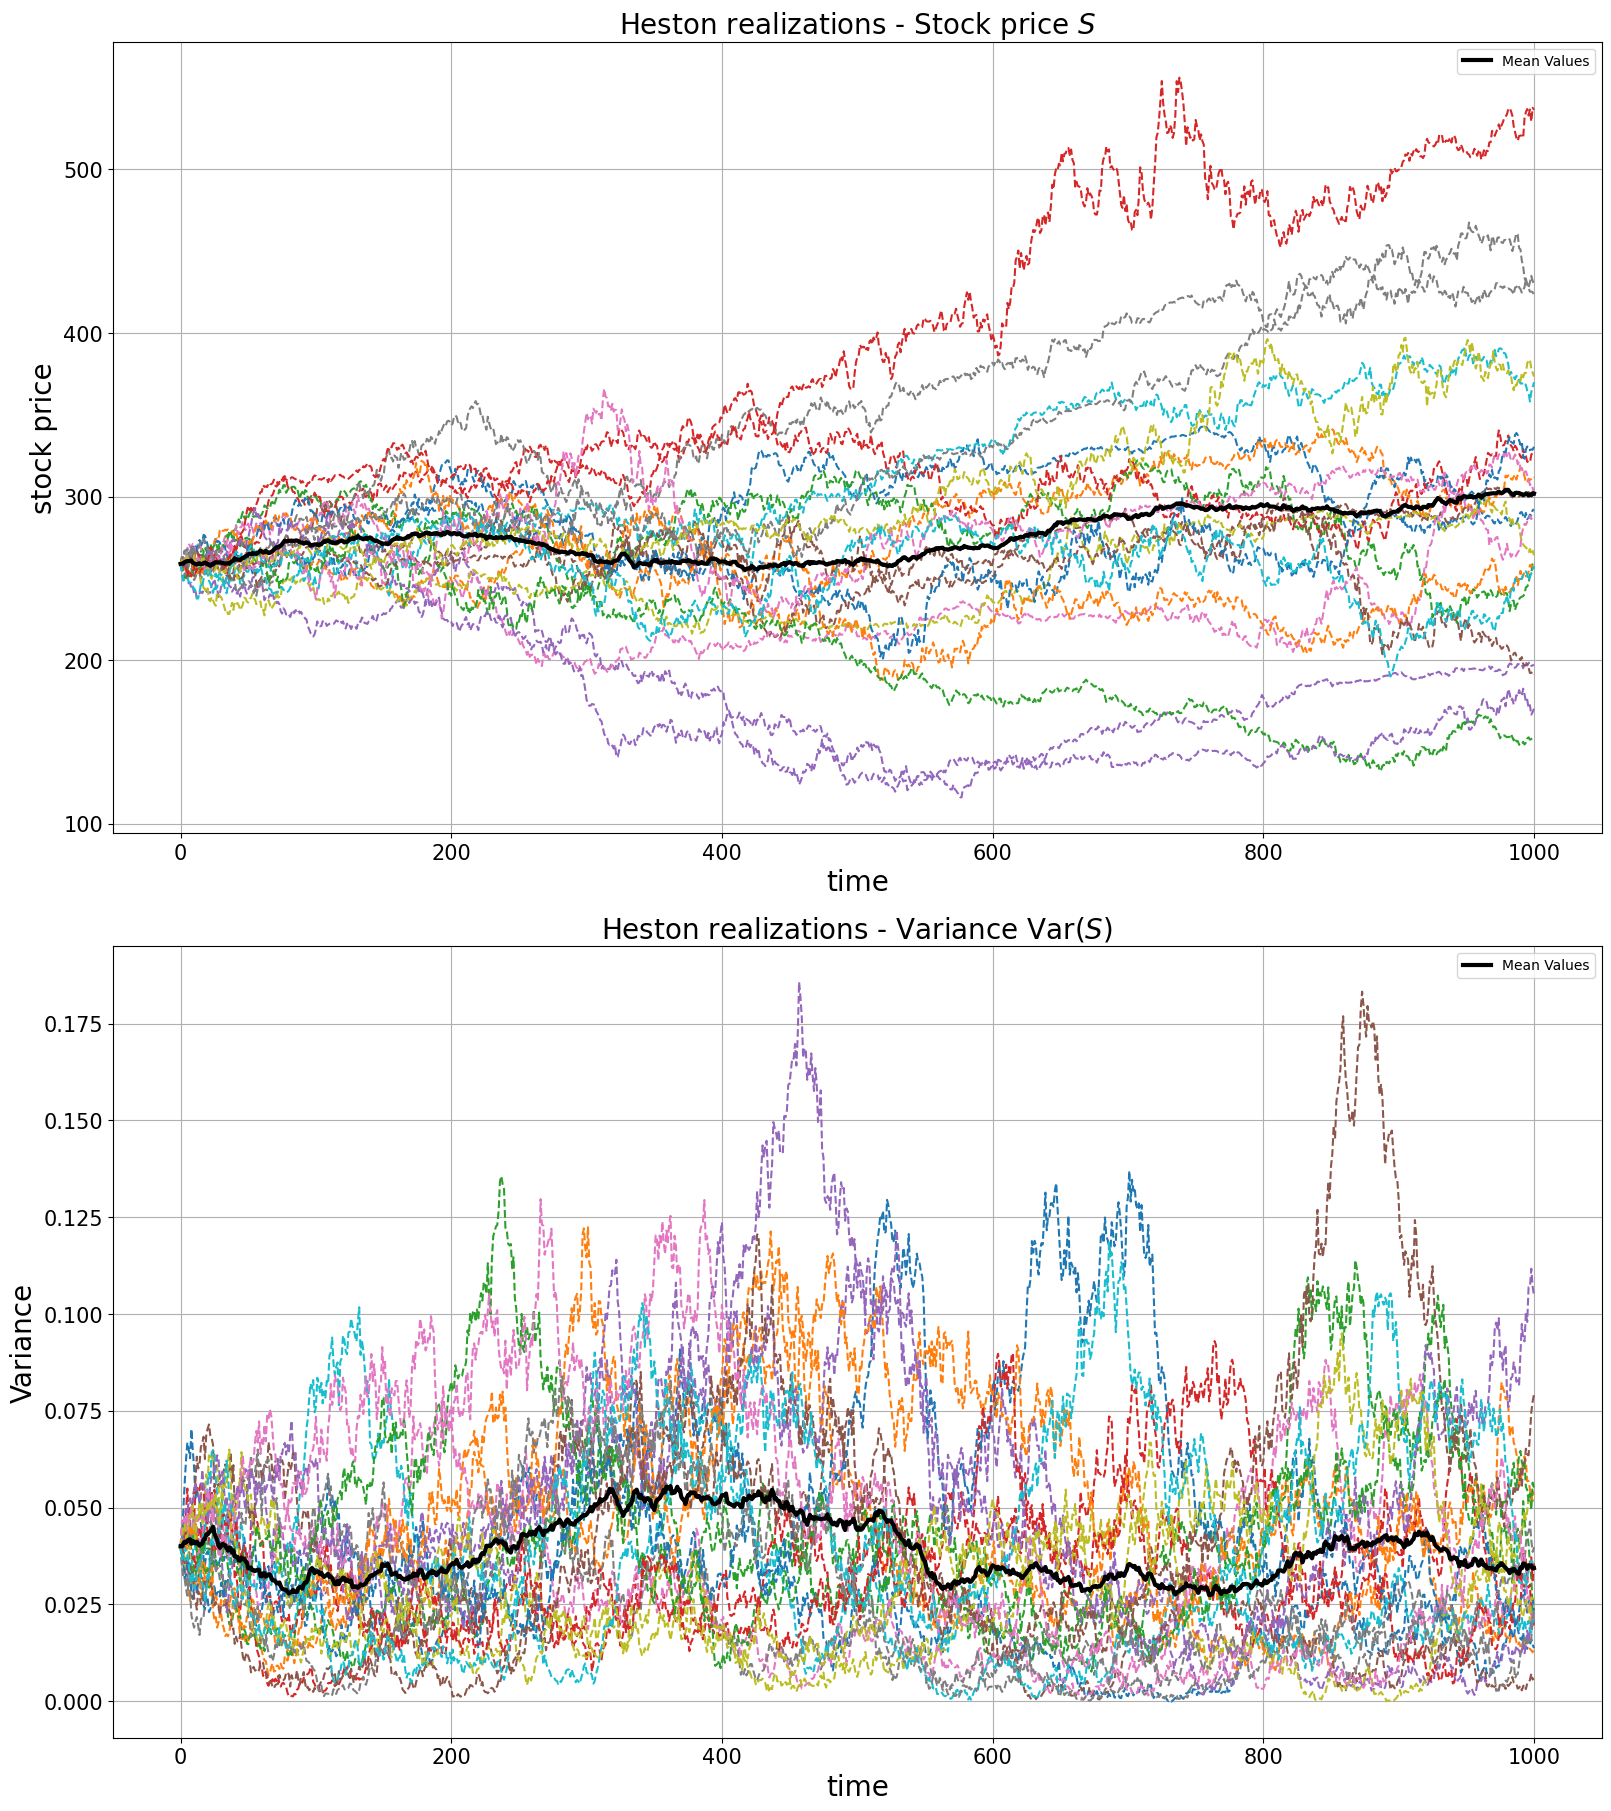

In [16]:
fig, axs = plt.subplots(2, 1, figsize=(16, 18), layout='constrained')

axs[0].plot(S.T, '--')
axs[0].plot(np.mean(S, axis=0), label='Mean Values', c='k', lw=3)
axs[0].set_xlabel('time')
axs[0].set_ylabel('stock price')
axs[0].grid(True)
axs[0].set_title(r'Heston realizations - Stock price $S$')
axs[0].legend()

axs[1].plot(V.T, '--')
axs[1].plot(np.mean(V, axis=0), label='Mean Values', c='k', lw=3)
axs[1].set_xlabel('time')
axs[1].set_ylabel('Variance')
axs[1].grid(True)
axs[1].set_title(r'Heston realizations - Variance Var$(S)$')
axs[1].legend()

plt.show()

## Benchmarking Monte Carlo of Heston Model

### Convergence check

 - Note that here we need to check the convergence of both time discretization and number of samples

In [43]:
TICKER = "AAPL"

data = yf.download(TICKER, period="1y")["Close"]
log_returns = np.log(data / data.shift(1)).dropna()
r_free = 3.7e-2         # as of 05.04.2026
S0 = data.iloc[-1, 0]
# sigma_year = log_returns.std()[TICKER] * np.sqrt(252) 

today = pd.Timestamp.today().normalize()
expiry = pd.Timestamp("2028-12-15")
trading_days = pd.bdate_range(today, expiry)  # business days only
n = len(trading_days)
T = n / 252

[*********************100%***********************]  1 of 1 completed


#### time discretization

In [44]:
is_antithetic = [False, True]
NUM_STEPS = np.round(np.geomspace(5, 5000, num=10)).astype(int) 

result_price = {
    'Naive': [],
    'Antithetic': []
}
result_variance = {
    'Naive': [],
    'Antithetic': []
}


In [45]:
mc = MonteCarlo_Heston(USE_NUMBA=True)
mc.load(S0=S0, K=210, r_free=r_free, v0=0.04, kappa=2, theta=0.04, xi=0.3, rho=-0.5)
_, _ = mc.mc_simulation(T, n_samples=5, n_steps=10)

In [46]:
# with numba
import time, sys
for n_step in np.nditer(NUM_STEPS):
    start = time.time()
    C, sigma = mc.mc_simulation(T, n_samples=500000, n_steps=int(n_step), antithetic=False)
    result_price['Naive'].append(C)
    result_variance['Naive'].append(sigma)
    end = time.time()
    print('Time cost ({} steps): '.format(n_step), '{:.2f} s'.format(end - start), flush=True)

    C, sigma = mc.mc_simulation(T, n_samples=500000, n_steps=int(n_step), antithetic=True)
    result_price['Antithetic'].append(C)
    result_variance['Antithetic'].append(sigma)

Time cost (5 steps):  0.08 s
Time cost (11 steps):  0.18 s
Time cost (23 steps):  0.36 s
Time cost (50 steps):  0.79 s
Time cost (108 steps):  1.71 s
Time cost (232 steps):  3.72 s
Time cost (500 steps):  8.08 s
Time cost (1077 steps):  17.26 s
Time cost (2321 steps):  37.60 s
Time cost (5000 steps):  80.47 s


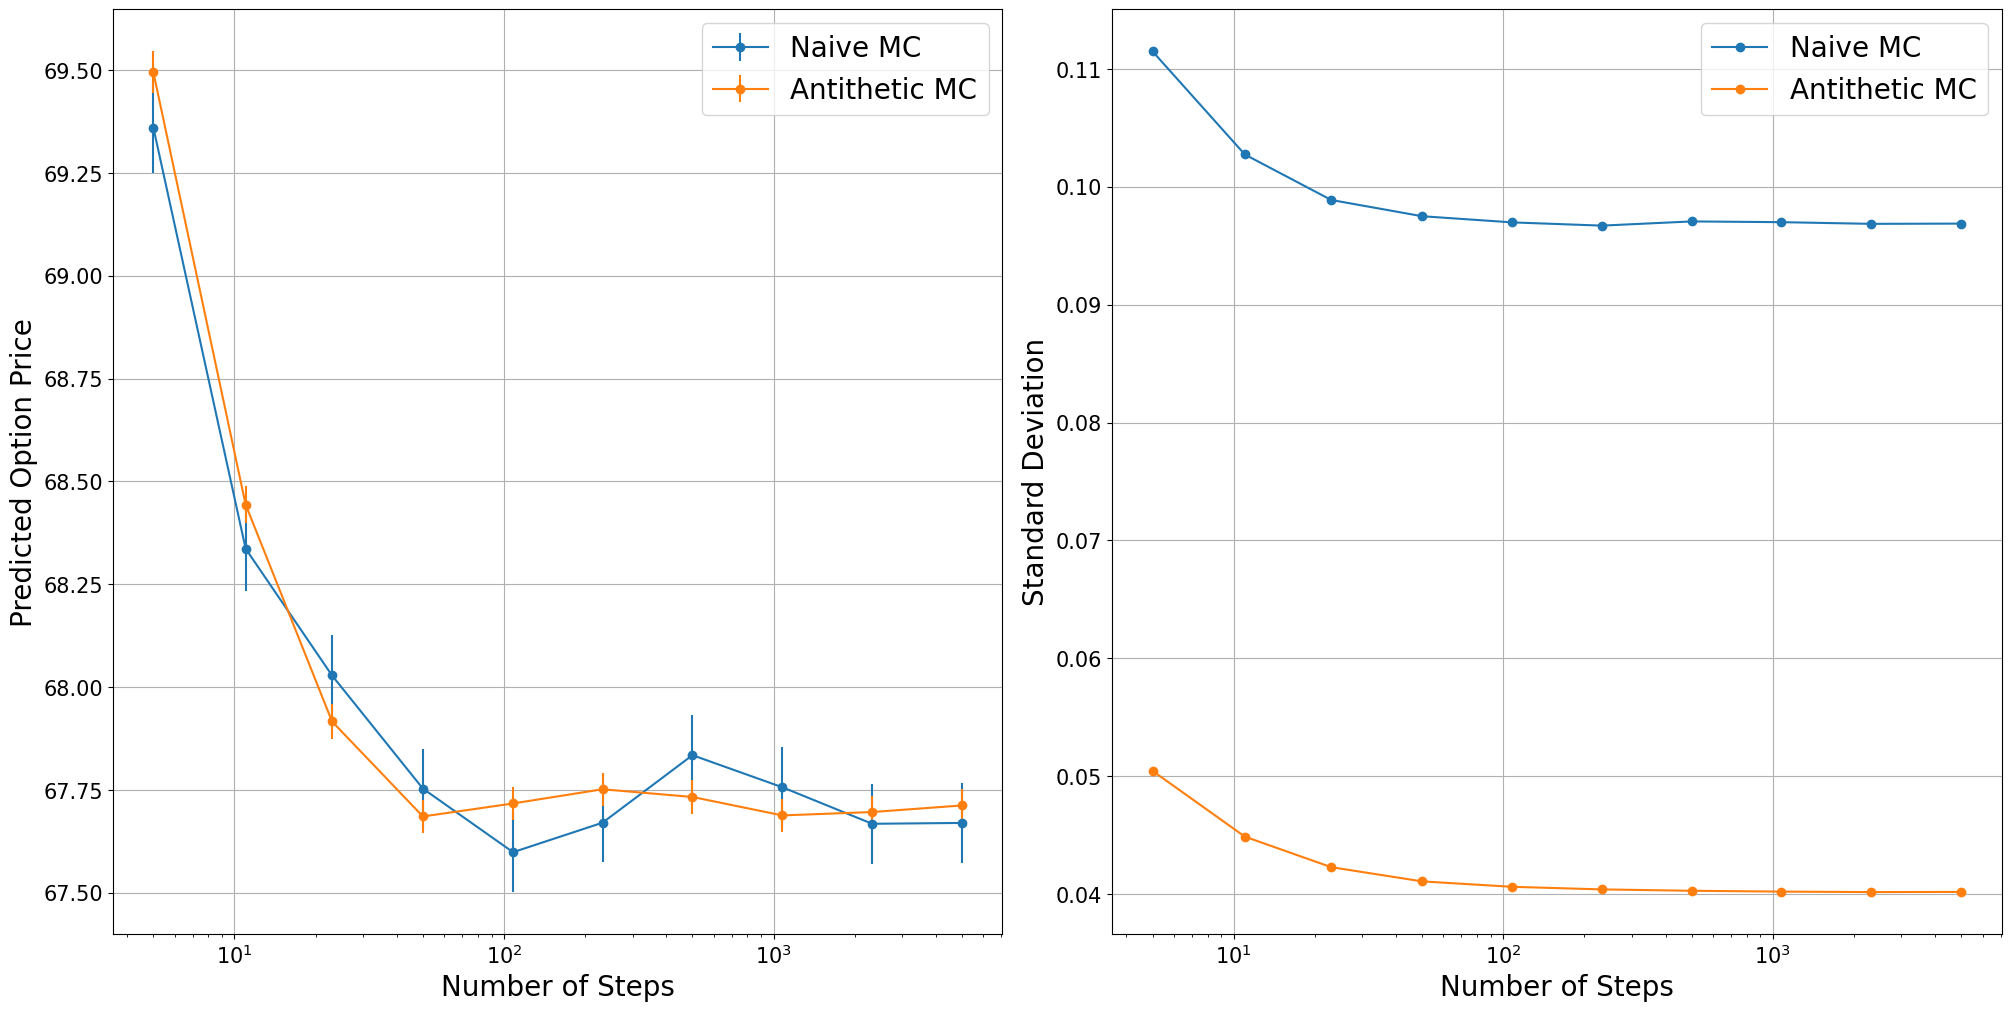

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10), layout='constrained')

axs[0].errorbar(NUM_STEPS, result_price['Naive'], yerr=result_variance['Naive'], marker='o', label='Naive MC')
axs[0].errorbar(NUM_STEPS, result_price['Antithetic'], yerr=result_variance['Antithetic'], marker='o', label='Antithetic MC')
axs[0].set_xlabel('Number of Steps')
axs[0].set_ylabel('Predicted Option Price')
axs[0].legend(fontsize=20)
axs[0].set_xscale('log')
axs[0].grid(True)

# k1, _ = np.polyfit(np.log(NUM_STEPS), np.log(result_variance['Naive']), deg=1)
# k2, _ = np.polyfit(np.log(NUM_STEPS), np.log(result_variance['Naive']), deg=1)
axs[1].plot(NUM_STEPS, result_variance['Naive'], '-o', label='Naive MC')
axs[1].plot(NUM_STEPS, result_variance['Antithetic'], '-o', label='Antithetic MC')
axs[1].set_xlabel('Number of Steps')
axs[1].set_ylabel('Standard Deviation')
axs[1].set_xscale('log')
axs[1].legend(fontsize=20)
axs[1].grid(True)

plt.show()

One could observe that the choice of time discretization is essential to guarantee a convergent result. In this case, one can argue that `n_steps > 500` can be a reasonable choice.

#### number of samples

In [9]:
is_antithetic = [False, True]
NUM_SAMPS = np.round(np.geomspace(1e4, 1e7, num=10)).astype(int) 

result_price = {
    'Naive': [],
    'Antithetic': []
}
result_variance = {
    'Naive': [],
    'Antithetic': []
}

In [10]:
mc = MonteCarlo_Heston(USE_NUMBA=True)
mc.load(S0=S0, K=210, r_free=r_free, v0=0.04, kappa=2, theta=0.04, xi=0.3, rho=-0.5)
_, _ = mc.mc_simulation(T, n_samples=5, n_steps=10)

In [11]:
# with numba
import time, sys
for n_samps in np.nditer(NUM_SAMPS):
    start = time.time()
    C, sigma = mc.mc_simulation(T, n_samples=int(n_samps), n_steps=500, antithetic=False)
    result_price['Naive'].append(C)
    result_variance['Naive'].append(sigma)
    end = time.time()
    print('Time cost ({} samps): '.format(n_samps), '{:.2f} s'.format(end - start), flush=True)

    C, sigma = mc.mc_simulation(T, n_samples=int(n_samps), n_steps=500, antithetic=True)
    result_price['Antithetic'].append(C)
    result_variance['Antithetic'].append(sigma)

Time cost (10000 steps):  0.17 s
Time cost (21544 steps):  0.35 s
Time cost (46416 steps):  0.74 s
Time cost (100000 steps):  1.62 s
Time cost (215443 steps):  3.48 s
Time cost (464159 steps):  7.48 s
Time cost (1000000 steps):  16.02 s
Time cost (2154435 steps):  34.50 s
Time cost (4641589 steps):  74.17 s
Time cost (10000000 steps):  159.08 s


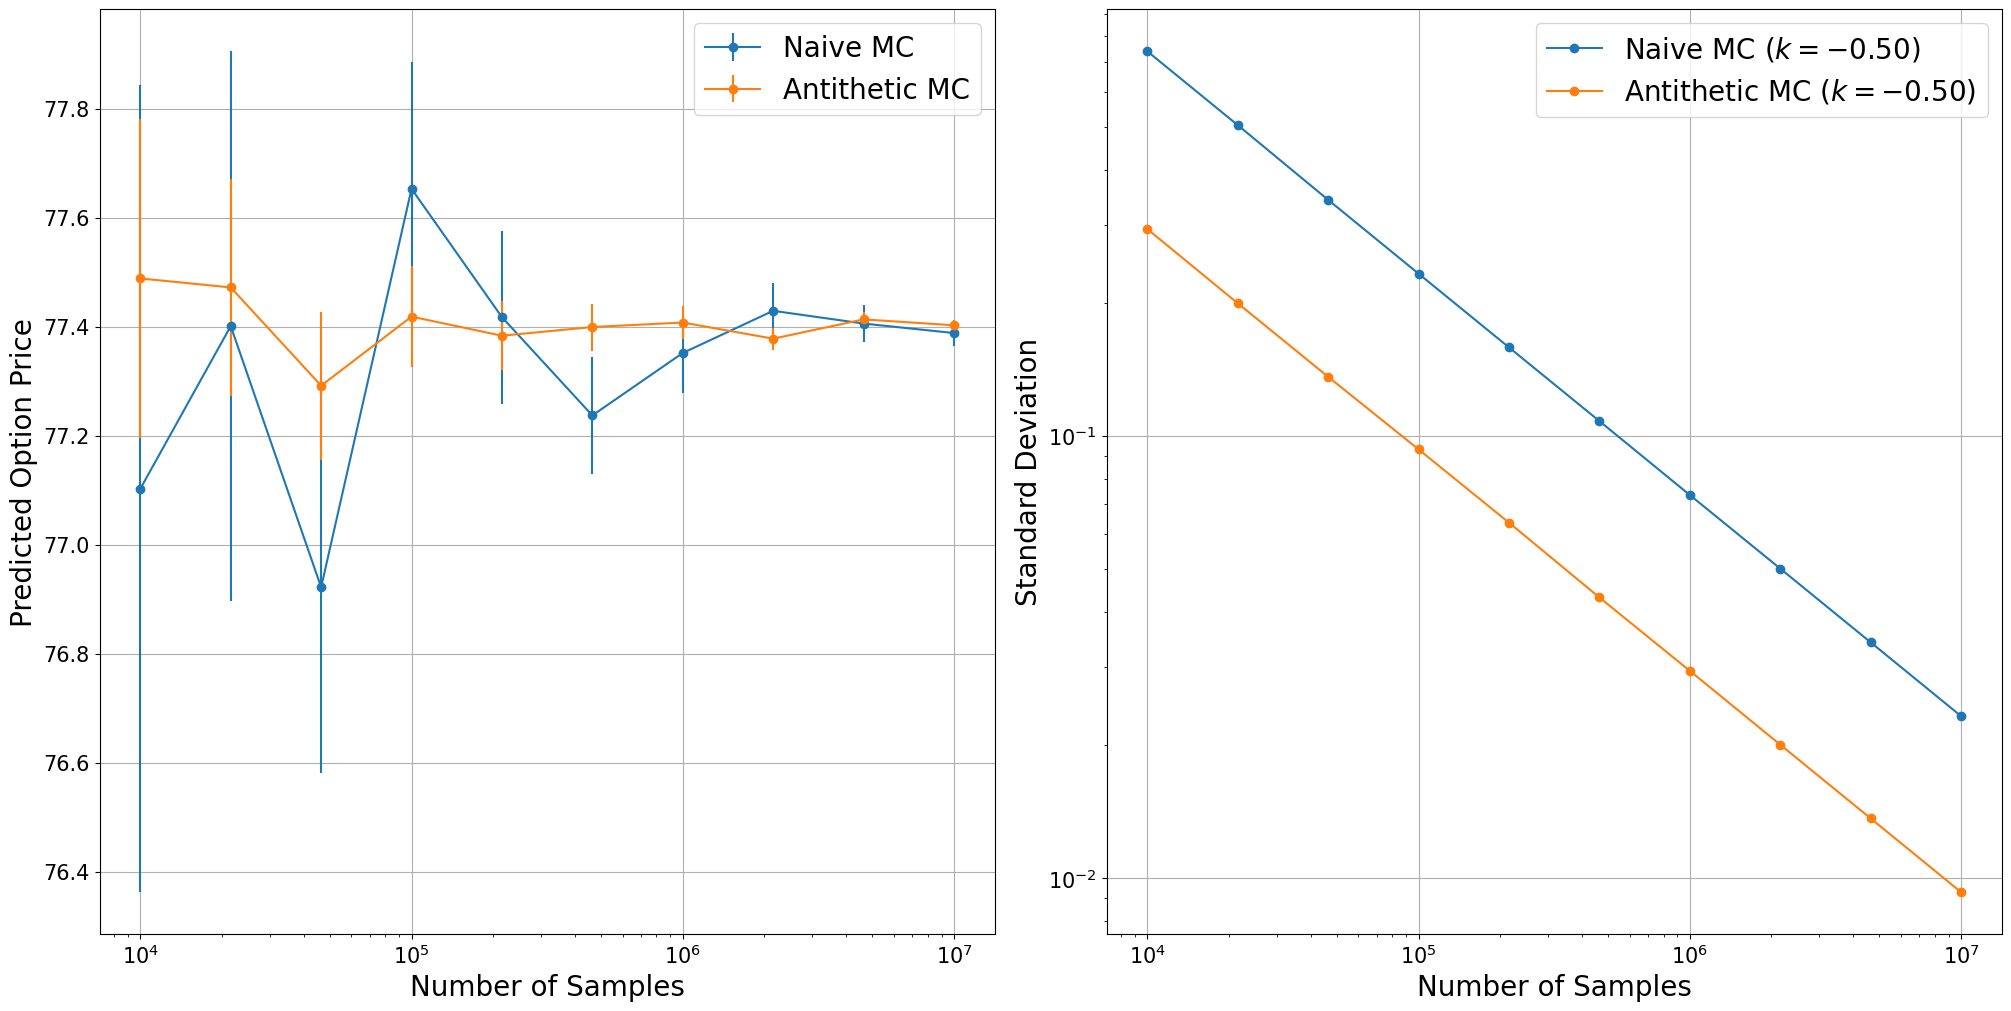

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10), layout='constrained')

axs[0].errorbar(NUM_SAMPS, result_price['Naive'], yerr=result_variance['Naive'], marker='o', label='Naive MC')
axs[0].errorbar(NUM_SAMPS, result_price['Antithetic'], yerr=result_variance['Antithetic'], marker='o', label='Antithetic MC')
axs[0].set_xlabel('Number of Samples')
axs[0].set_ylabel('Predicted Option Price')
axs[0].legend(fontsize=20)
axs[0].set_xscale('log')
axs[0].grid(True)

k1, _ = np.polyfit(np.log(NUM_SAMPS), np.log(result_variance['Naive']), deg=1)
k2, _ = np.polyfit(np.log(NUM_SAMPS), np.log(result_variance['Naive']), deg=1)
axs[1].loglog(NUM_SAMPS, result_variance['Naive'], '-o', label=r'Naive MC ($k={:.2f}$)'.format(k1))
axs[1].loglog(NUM_SAMPS, result_variance['Antithetic'], '-o', label=r'Antithetic MC ($k={:.2f}$)'.format(k2))
axs[1].set_xlabel('Number of Samples')
axs[1].set_ylabel('Standard Deviation')
axs[1].legend(fontsize=20)
axs[1].grid(True)

plt.show()

Again,
- The variation show decays as $\sim \frac{1}{\sqrt{N}}$ for both methods.

### Compare with analytical and real market data

**(!)Note: again, for better visualization, the code in this subsection is written assisted by Claude Code**

In [53]:
# ── AAPL data + fixed Heston parameters ──────────────────────────────────────
TICKER_H = "AAPL"
raw_h    = yf.download(TICKER_H, period="1y", auto_adjust=True, progress=False)["Close"]
log_ret_h = np.log(raw_h / raw_h.shift(1)).dropna()
S0_h     = raw_h.iloc[-1, 0]
sigma_h  = float(log_ret_h.std()) * np.sqrt(252)   # historical vol (used only as reference)
r_free_h = 3.7e-2
today_h  = pd.Timestamp.today().normalize()

# Heston parameters (fixed; see parameter calibration discussion below)
H_PARAMS = dict(v0=0.04, kappa=2.0, theta=0.04, xi=0.3, rho=-0.5)

N_MC_H    = int(2e5)    # MC samples
N_STEPS_H = 200         # time steps per path (converged regime from earlier section)

# Warm-up: trigger numba JIT compilation once
_mc_warm = MonteCarlo_Heston(USE_NUMBA=True)
_mc_warm.load(S0_h, S0_h, r_free_h, **H_PARAMS)
_, _ = _mc_warm.mc_simulation(0.5, n_samples=5, n_steps=10)

print(f"{TICKER_H}  S0={S0_h:.2f}  sigma_hist={sigma_h:.4f}")
print("Heston params:", H_PARAMS)


/var/folders/yn/fdszgfc909s08rlqym77kbhh0000gn/T/ipykernel_41285/2170413074.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma_h  = float(log_ret_h.std()) * np.sqrt(252)   # historical vol (used only as reference)


AAPL  S0=250.01  sigma_hist=0.2879
Heston params: {'v0': 0.04, 'kappa': 2.0, 'theta': 0.04, 'xi': 0.3, 'rho': -0.5}


In [55]:
# ── Benchmark A: 10 expiry dates, same (near-ATM) strike ─────────────────────
stock_h = yf.Ticker(TICKER_H)
expiries_h = pick_expiries(stock_h.options, n=10)

# Find a strike present in ALL 10 chains and closest to ATM
chains_h = {e: stock_h.option_chain(e).calls for e in expiries_h}
common_strikes_h = set(chains_h[expiries_h[0]]["strike"])
for e in expiries_h[1:]:
    common_strikes_h &= set(chains_h[e]["strike"])
strike_h = min(common_strikes_h, key=lambda k: abs(k - S0_h))

rows_A = []
for e in expiries_h:
    T = T_from_expiry(e)

    pricer = MonteCarlo_Heston(USE_NUMBA=True)
    pricer.load(S0_h, strike_h, r_free_h, **H_PARAMS)

    mc_price, mc_se    = pricer.mc_simulation(T, n_samples=N_MC_H, n_steps=N_STEPS_H)
    heston_price       = pricer.heston_price(T)
    mkt_last, mkt_mid  = get_market_price(chains_h[e], strike_h)

    rows_A.append({
        "Expiry":        e,
        "Strike":        strike_h,
        "T (yr)":        round(T, 3),
        "MC Price":      round(mc_price,    3),
        "MC ±2σ": round(2 * mc_se, 3),
        "Heston Price":  round(heston_price, 3),
        "Mkt Last":      round(mkt_last, 3) if not np.isnan(mkt_last) else np.nan,
        "Mkt Mid":       round(mkt_mid,  3) if not np.isnan(mkt_mid)  else np.nan,
    })
    print(f"  {e}  MC={mc_price:.3f}  Heston={heston_price:.3f}  Mkt={mkt_last:.3f}", flush=True)

results_hA = pd.DataFrame(rows_A)
print("", results_hA.to_string(index=False))


  2026-04-08  MC=1.819  Heston=1.684  Mkt=1.450
  2026-04-13  MC=2.899  Heston=2.890  Mkt=3.050
  2026-04-20  MC=4.144  Heston=4.151  Mkt=4.800
  2026-05-08  MC=6.563  Heston=6.563  Mkt=9.000
  2026-05-22  MC=7.905  Heston=7.894  Mkt=10.400
  2026-08-21  MC=14.076  Heston=14.103  Mkt=19.100
  2026-11-20  MC=18.752  Heston=18.752  Mkt=24.650
  2027-01-15  MC=21.299  Heston=21.276  Mkt=29.070
  2027-12-17  MC=33.870  Heston=33.896  Mkt=45.410
  2028-12-15  MC=45.153  Heston=45.036  Mkt=58.200
     Expiry  Strike  T (yr)  MC Price  MC ±2σ  Heston Price  Mkt Last  Mkt Mid
2026-04-08   250.0   0.008     1.819   0.006         1.684      1.45    1.450
2026-04-13   250.0   0.020     2.899   0.009         2.890      3.05    3.050
2026-04-20   250.0   0.040     4.144   0.013         4.151      4.80    4.750
2026-05-08   250.0   0.095     6.563   0.020         6.563      9.00    8.975
2026-05-22   250.0   0.135     7.905   0.023         7.894     10.40   10.325
2026-08-21   250.0   0.393    14.07

In [57]:
# ── Benchmark B: 10 strikes, same (mid-range) expiry ─────────────────────────

def pick_strikes_n(chain_calls, S0, n=10):
    """Pick n strikes evenly spread around ATM."""
    strikes = sorted(chain_calls["strike"].unique())
    atm_idx = min(range(len(strikes)), key=lambda i: abs(strikes[i] - S0))
    half    = n // 2
    lo = max(0, atm_idx - half)
    hi = lo + n
    if hi > len(strikes):
        hi = len(strikes)
        lo = max(0, hi - n)
    return [strikes[i] for i in range(lo, hi)]

future_exp_h = [e for e in stock_h.options if pd.Timestamp(e) > today_h]
expiry_B     = future_exp_h[len(future_exp_h) // 3]      # ~1/3 into available range
T_B          = T_from_expiry(expiry_B)
chain_B      = stock_h.option_chain(expiry_B).calls
strikes_B    = pick_strikes_n(chain_B, S0_h, n=10)

rows_B = []
for K in strikes_B:
    pricer = MonteCarlo_Heston(USE_NUMBA=True)
    pricer.load(S0_h, K, r_free_h, **H_PARAMS)

    mc_price, mc_se    = pricer.mc_simulation(T_B, n_samples=N_MC_H, n_steps=N_STEPS_H)
    heston_price       = pricer.heston_price(T_B)
    mkt_last, mkt_mid  = get_market_price(chain_B, K)

    moneyness = "ATM" if abs(K - S0_h) / S0_h < 0.03 else ("ITM" if K < S0_h else "OTM")
    rows_B.append({
        "Strike":        K,
        "Moneyness":     moneyness,
        "T (yr)":        round(T_B, 3),
        "MC Price":      round(mc_price,     3),
        "MC ±2σ": round(2 * mc_se, 3),
        "Heston Price":  round(heston_price, 3),
        "Mkt Last":      round(mkt_last, 3) if not np.isnan(mkt_last) else np.nan,
        "Mkt Mid":       round(mkt_mid,  3) if not np.isnan(mkt_mid)  else np.nan,
    })
    print(f"  K={K:.0f} ({moneyness})  MC={mc_price:.3f}  Heston={heston_price:.3f}  Mkt={mkt_last:.3f}", flush=True)

results_hB = pd.DataFrame(rows_B)
print(f"{TICKER_H} — expiry {expiry_B} (T={T_B:.3f} yr)")
print(results_hB.to_string(index=False))


  K=225 (ITM)  MC=26.157  Heston=26.159  Mkt=31.650
  K=230 (ITM)  MC=21.514  Heston=21.518  Mkt=21.700
  K=235 (ITM)  MC=17.126  Heston=17.124  Mkt=18.500
  K=240 (ITM)  MC=13.082  Heston=13.090  Mkt=13.820
  K=245 (ATM)  MC=9.525  Heston=9.535  Mkt=11.240
  K=250 (ATM)  MC=6.557  Heston=6.563  Mkt=9.000
  K=255 (ATM)  MC=4.237  Heston=4.232  Mkt=6.550
  K=260 (OTM)  MC=2.532  Heston=2.537  Mkt=4.550
  K=265 (OTM)  MC=1.403  Heston=1.404  Mkt=3.070
  K=270 (OTM)  MC=0.714  Heston=0.715  Mkt=2.050
AAPL — expiry 2026-05-08 (T=0.095 yr)
 Strike Moneyness  T (yr)  MC Price  MC ±2σ  Heston Price  Mkt Last  Mkt Mid
  225.0       ITM   0.095    26.157   0.009        26.159     31.65   26.550
  230.0       ITM   0.095    21.514   0.010        21.518     21.70   22.400
  235.0       ITM   0.095    17.126   0.012        17.124     18.50   18.800
  240.0       ITM   0.095    13.082   0.015        13.090     13.82   15.000
  245.0       ATM   0.095     9.525   0.018         9.535     11.24   11.6

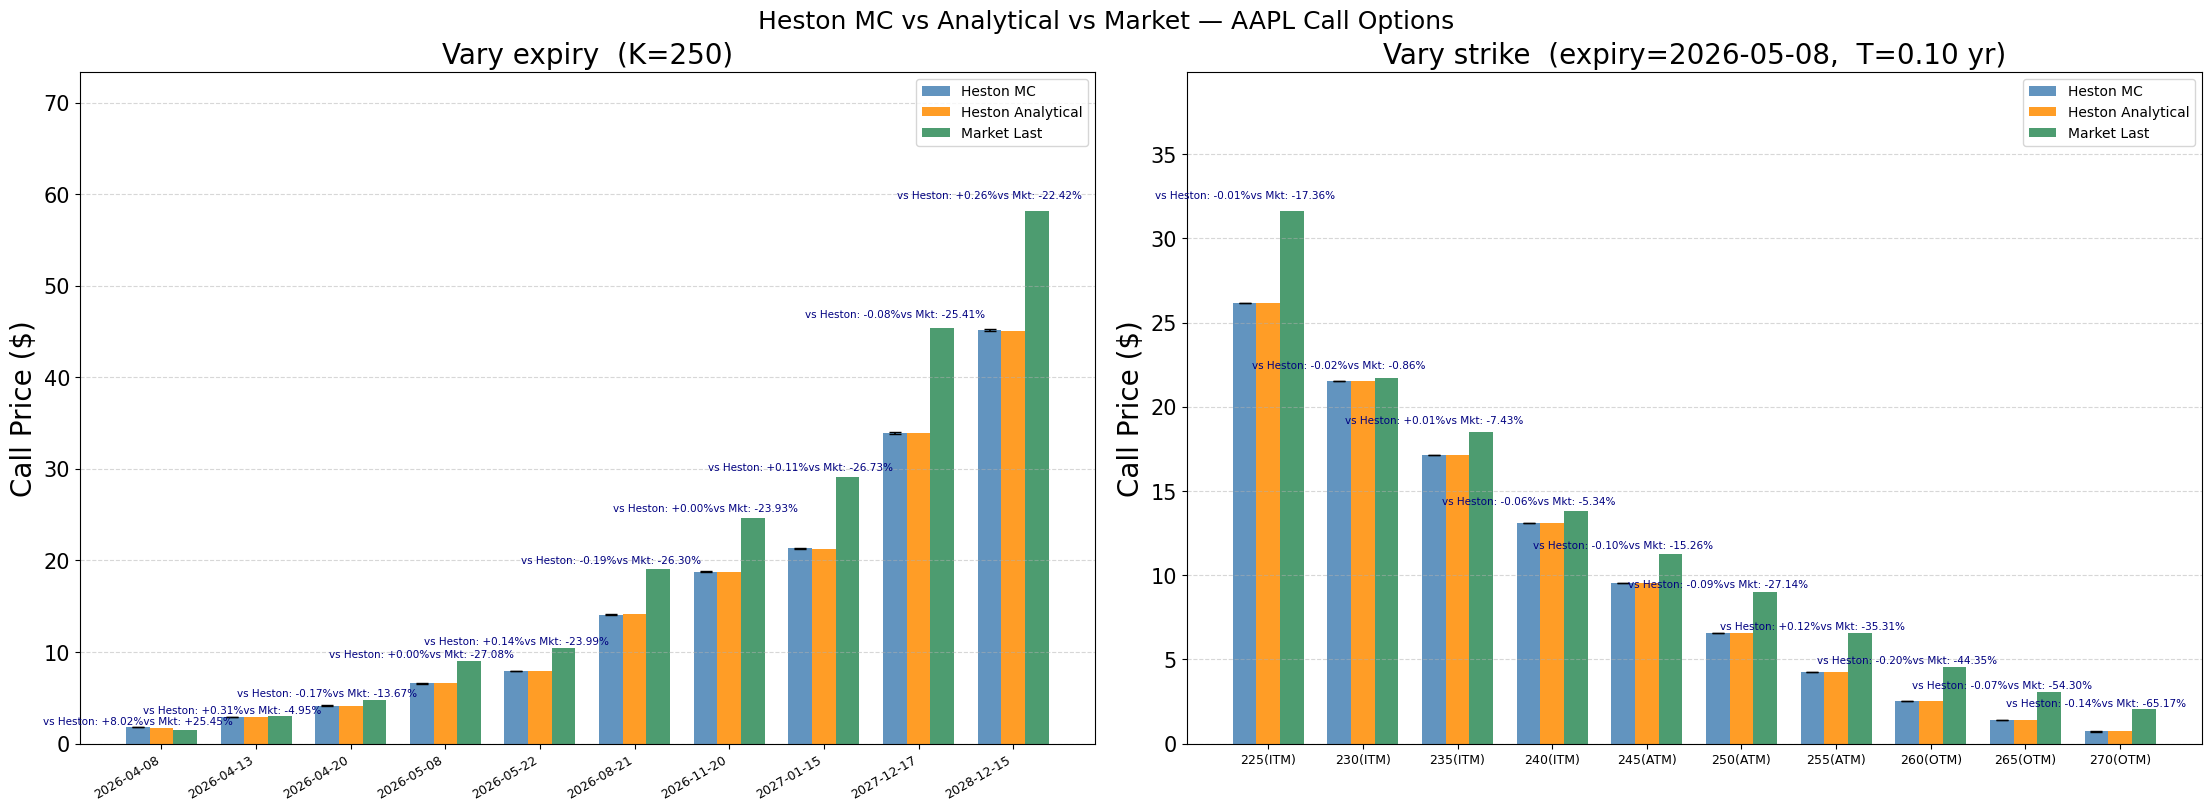

In [60]:
# ── Visualisation ─────────────────────────────────────────────────────────────

def annotate_heston_rel_diff(ax, x_positions, df, bar_width):
    """Annotate MC bar with (MC-Heston)/Heston and (MC-Mkt)/Mkt."""
    for xi, (_, row) in zip(x_positions, df.iterrows()):
        mc  = row["MC Price"]
        ref = row["Heston Price"]
        mkt = row["Mkt Last"]

        candidates = [mc, ref] + ([mkt] if not np.isnan(mkt) else [])
        y_top = max(candidates) * 1.02

        lines = []
        if ref > 0:
            lines.append(f"vs Heston: {(mc-ref)/ref*100:+.2f}%")
        if not np.isnan(mkt) and mkt > 0:
            lines.append(f"vs Mkt: {(mc-mkt)/mkt*100:+.2f}%")
        if lines:
            ax.text(xi - bar_width, y_top, "".join(lines),
                    ha="center", va="bottom", fontsize=7.5,
                    color="navy", linespacing=1.4)


fig, axes = plt.subplots(1, 2, figsize=(22, 8), layout="constrained")
fig.suptitle(f"Heston MC vs Analytical vs Market — {TICKER_H} Call Options", fontsize=18)

w = 0.25

# ── panel A: vary expiry ──────────────────────────────────────────────────────
ax = axes[0]
df = results_hA
x  = np.arange(len(df))

ax.bar(x - w, df["MC Price"],     w, label="Heston MC",         color="steelblue",  alpha=0.85)
ax.bar(x,     df["Heston Price"], w, label="Heston Analytical", color="darkorange", alpha=0.85)
ax.bar(x + w, df["Mkt Last"],     w, label="Market Last",       color="seagreen",   alpha=0.85)
ax.errorbar(x - w, df["MC Price"], yerr=df["MC ±2σ"],
            fmt="none", color="black", capsize=4, linewidth=1.2)
annotate_heston_rel_diff(ax, x, df, w)

ax.set_xticks(x)
ax.set_xticklabels(df["Expiry"], rotation=30, ha="right", fontsize=9)
ax.set_title(f"Vary expiry  (K={df['Strike'].iloc[0]:.0f})")
ax.set_ylabel("Call Price ($)")
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(top=ax.get_ylim()[1] * 1.20)

# ── panel B: vary strike ──────────────────────────────────────────────────────
ax = axes[1]
df = results_hB
x  = np.arange(len(df))

ax.bar(x - w, df["MC Price"],     w, label="Heston MC",         color="steelblue",  alpha=0.85)
ax.bar(x,     df["Heston Price"], w, label="Heston Analytical", color="darkorange", alpha=0.85)
ax.bar(x + w, df["Mkt Last"],     w, label="Market Last",       color="seagreen",   alpha=0.85)
ax.errorbar(x - w, df["MC Price"], yerr=df["MC ±2σ"],
            fmt="none", color="black", capsize=4, linewidth=1.2)
annotate_heston_rel_diff(ax, x, df, w)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{row.Strike:.0f}({row.Moneyness})" for row in df.itertuples()],
    fontsize=9)
ax.set_title(f"Vary strike  (expiry={expiry_B},  T={T_B:.2f} yr)")
ax.set_ylabel("Call Price ($)")
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(top=ax.get_ylim()[1] * 1.20)

plt.show()


1. **The Monte Carlo simulation agrees well with the analytical solution, so there is no systematic error.**
2. However, due to the extra degrees of freedom in the model parameters, one needs to fine-tune them to match the real market data; A set of randomly selected parameters could not give satisfying results.

To find the suitable set of parameters, one might resort to linear regression to minimize 
$$L=\frac{1}{2}\sum_{i}(C_i^{H} - C_i^{M})^2$$
where $C_i^{H}$ is the predicted price of the Heston model and $C_i^{M}$ is the actual market prices.